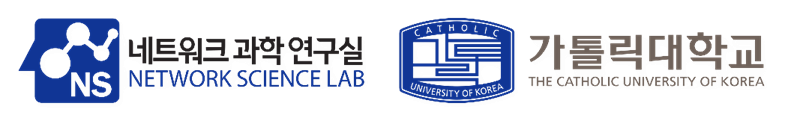

# Practice Code 2: Message Passing Mechanism & Graph Neural Network

In [ ]:
# !pip install matplotlib
# !pip install -U scikit-learn
# !pip install torch_geometric
# !pip install networkx
# !pip install torch torchvision torchaudio
# # !pip install dgl

## 1.1. Imports and plot settings

In [1]:
import random

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import networkx as nx
import torch
import torch.nn as nn
import torch.nn.functional as F
from matplotlib.lines import Line2D
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from torch_geometric.data import Data
from torch_geometric.datasets import KarateClub
from torch_geometric.nn import GCNConv, MessagePassing
from torch_geometric.utils import add_self_loops, degree, to_dense_adj, to_networkx

# Set random seeds
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# Plot settings
plt.rcParams["figure.figsize"] = (12, 8)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["font.size"] = 12

# Karate Club colors: administrator (Mr. Hi) vs instructor (Officer)
CLUB_COLORS = {0: "#E74C3C", 1: "#3498DB"}
CLUB_NAMES = {0: "Mr. Hi (administrator)", 1: "Officer (instructor)"}

print(f"PyTorch version: {torch.__version__}")
print(f"NumPy version:   {np.__version__}")

/home/linux/miniconda3/envs/GNN/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/linux/miniconda3/envs/GNN/lib/python3.14/site-packages/torch/jit/_script.py:1485: FutureWarning: `torch.jit.script` is not supported in Python 3.14+ and may break. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


PyTorch version: 2.14.0+cu130
NumPy version:   2.5.3


---

# 2. Graph Construction

PyG represents a graph with an **edge index** of shape `[2, num_edges]`, not a dense adjacency matrix.
The first row is the source nodes and the second row is the destination nodes.

## 2.1. A simple 3-node graph

In [2]:
edge_index = torch.tensor(
    [
        [0, 1, 1, 2],
        [1, 0, 2, 1],
    ],
    dtype=torch.long,
)

x = torch.tensor(
    [
        [-1.0],
        [0.0],
        [1.0],
    ],
    dtype=torch.float,
)

simple_graph = Data(x=x, edge_index=edge_index)

print(simple_graph)
print("Number of nodes:", simple_graph.num_nodes)
print("Number of edges:", simple_graph.num_edges)
print("Node features:\n", simple_graph.x)
print("Edge index:\n", simple_graph.edge_index)

Data(x=[3, 1], edge_index=[2, 4])
Number of nodes: 3
Number of edges: 4
Node features:
 tensor([[-1.],
        [ 0.],
        [ 1.]])
Edge index:
 tensor([[0, 1, 1, 2],
        [1, 0, 2, 1]])


## 2.2. Zachary's Karate Club

In [3]:
# Load the Karate Club graph
dataset = KarateClub()
data = dataset[0]

# Use the original two-way split: instructor (Officer) vs. administrator (Mr. Hi)
club_graph = nx.karate_club_graph()
data.y = torch.tensor(
    [0 if club_graph.nodes[node]["club"] == "Mr. Hi" else 1 for node in range(data.num_nodes)],
    dtype=torch.long,
)
num_classes = 2

# Label
data.train_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
data.train_mask[0] = True   # Mr. Hi
data.train_mask[33] = True  # Officer

print("=" * 60)
print("Karate Club - Dataset Summary")
print("=" * 60)
print(f"Number of nodes (members):     {data.num_nodes}")
print(f"Number of edges (connections): {data.num_edges}")
print(f"Number of node features:       {data.num_node_features}")
print(f"Number of classes (groups):    {num_classes}")
print(f"Has isolated nodes:            {data.has_isolated_nodes()}")
print(f"Has self-loops:                {data.has_self_loops()}")
print(f"Is undirected:                 {data.is_undirected()}")
print("=" * 60)
print(f"\nNode feature matrix shape: {data.x.shape}")
print(f"Edge index shape:          {data.edge_index.shape}")
print(f"Labels (y):                {data.y.tolist()}")
print(f"Train mask (labeled ids):  {data.train_mask.nonzero(as_tuple=False).view(-1).tolist()}")

Karate Club - Dataset Summary
Number of nodes (members):     34
Number of edges (connections): 156
Number of node features:       34
Number of classes (groups):    2
Has isolated nodes:            False
Has self-loops:                False
Is undirected:                 True

Node feature matrix shape: torch.Size([34, 34])
Edge index shape:          torch.Size([2, 156])
Labels (y):                [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Train mask (labeled ids):  [0, 33]


In [4]:
# Convert the dataset to a NetworkX graph and store the class on each node
G = to_networkx(data, to_undirected=True)
pos = nx.spring_layout(G, seed=42, k=0.5)

for node in G.nodes:
    G.nodes[node]["class"] = int(data.y[node])

# Retrieve all nodes in the karate graph along with their attributes
list(G.nodes(data=True))[:10]

[(0, {'class': 0}),
 (1, {'class': 0}),
 (2, {'class': 0}),
 (3, {'class': 0}),
 (4, {'class': 0}),
 (5, {'class': 0}),
 (6, {'class': 0}),
 (7, {'class': 0}),
 (8, {'class': 0}),
 (9, {'class': 1})]

### 2.3. Visualize the Karate Club graph

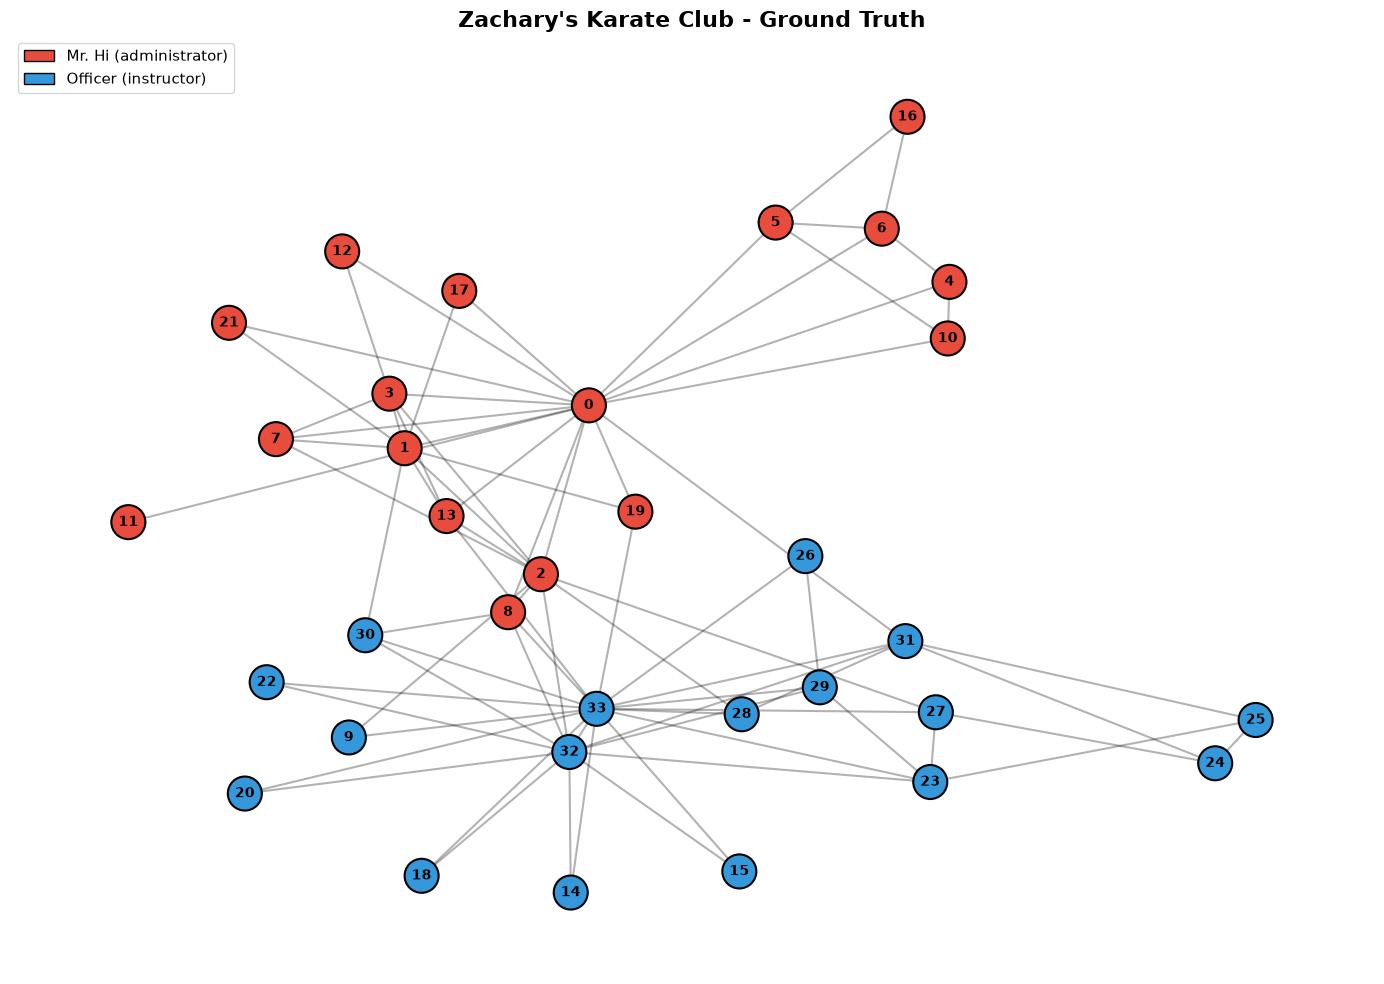

In [5]:
import matplotlib.patches as mpatches

def club_color_list(y):
    return [CLUB_COLORS[int(label)] for label in np.asarray(y)]


def club_legend(ax, loc="upper left"):
    handles = [
        mpatches.Patch(facecolor=CLUB_COLORS[i], edgecolor="black", label=CLUB_NAMES[i])
        for i in range(num_classes)
    ]
    ax.legend(handles=handles, loc=loc, fontsize=11)


labels = data.y.numpy()

fig, ax = plt.subplots(1, 1, figsize=(14, 10))
nx.draw_networkx_edges(G, pos, alpha=0.3, width=1.5, ax=ax)
nx.draw_networkx_nodes(
    G,
    pos,
    node_color=club_color_list(labels),
    node_size=600,
    edgecolors="black",
    linewidths=1.5,
    ax=ax,
)
nx.draw_networkx_labels(G, pos, font_size=10, font_weight="bold", ax=ax)
club_legend(ax)
ax.set_title("Zachary's Karate Club - Ground Truth", fontsize=16, fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.show()

### 2.4. Adjacency matrix and degree distribution

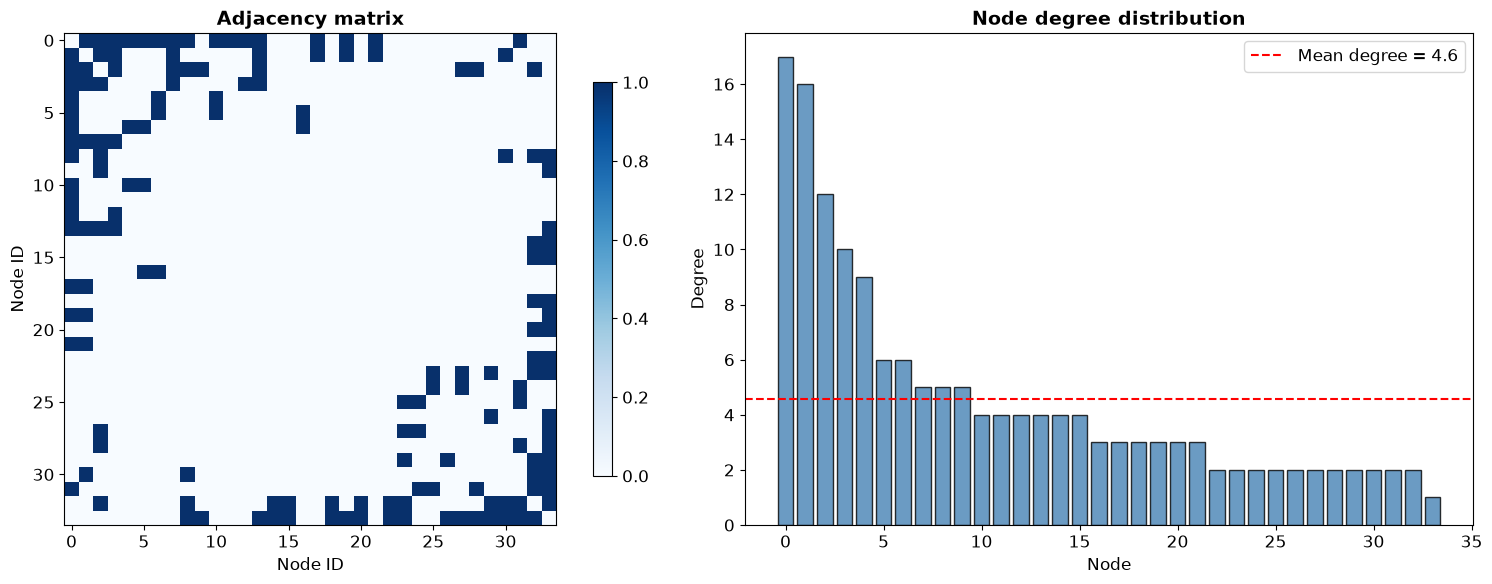

Degree statistics:
  Min degree:  1
  Max degree:  17 (Node 33)
  Mean degree: 4.59


In [6]:
adj_matrix = nx.adjacency_matrix(G).todense()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

im = axes[0].imshow(adj_matrix, cmap="Blues", interpolation="none")
axes[0].set_title("Adjacency matrix", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Node ID")
axes[0].set_ylabel("Node ID")
plt.colorbar(im, ax=axes[0], shrink=0.8)

degrees = [G.degree(n) for n in G.nodes()]
axes[1].bar(
    range(len(degrees)),
    sorted(degrees, reverse=True),
    color="steelblue",
    edgecolor="black",
    alpha=0.8,
)
axes[1].set_title("Node degree distribution", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Node")
axes[1].set_ylabel("Degree")
axes[1].axhline(
    y=np.mean(degrees),
    color="red",
    linestyle="--",
    label=f"Mean degree = {np.mean(degrees):.1f}",
)
axes[1].legend(fontsize=12)

plt.tight_layout()
plt.show()

print("Degree statistics:")
print(f"  Min degree:  {min(degrees)}")
print(f"  Max degree:  {max(degrees)} (Node {int(np.argmax(degrees))})")
print(f"  Mean degree: {np.mean(degrees):.2f}")

---

# 3. Relational Classification / Label Propagation

**Label Propagation Algorithm**
1. **Initialization**
   - Labeled nodes: $Y_v \leftarrow Y_v^*$
   - Unlabeled nodes: $Y_v \leftarrow 0.5$ (binary case)
2. **Iterative update** in a random order until convergence
   $$P(Y_v = c) = \frac{\sum_{u \in \mathcal{N}(v)} A_{vu}\, P(Y_u = c)}{\sum_{u \in \mathcal{N}(v)} A_{vu}}$$

## 3.1. Label Propagation on a small graph

In [7]:
def binary_label_propagation(graph, seed_labels, max_iters=10, seed=0):
    '''
    graph : nx.Graph
        Undirected graph used for label propagation.
    seed_labels : dict
        Ground-truth labels {node: 0 or 1} for the seed nodes.
    max_iters : int
        Maximum number of update sweeps.
    seed : int
        Random seed used to shuffle the update order.
    '''
    labeled = set(seed_labels.keys())
    Y = {}
    for node in graph.nodes:
        Y[node] = float(seed_labels[node]) if node in labeled else 0.5

    history = [dict(Y)]
    rng = random.Random(seed)

    for _ in range(max_iters):
        unlabeled = [n for n in graph.nodes if n not in labeled]
        rng.shuffle(unlabeled)

        # Each node uses the latest neighbor probabilities
        for v in unlabeled:
            neighbors = list(graph.neighbors(v))
            if not neighbors:
                continue
            Y[v] = sum(Y[u] for u in neighbors) / len(neighbors)

        history.append(dict(Y))
        prev = history[-2]
        if all(abs(Y[n] - prev[n]) < 1e-6 for n in graph.nodes):
            break

    return Y, history

In [8]:
# N(3) = {1, 2, 4}
# Seeds: nodes 1 and 2 are class 0; nodes 6 and 7 are class 1.
# Unlabeled nodes 3, 4, 5, 8, 9 start at 0.5.

example_graph = nx.Graph()
example_graph.add_edges_from(
    [
        (1, 3),
        (2, 3),
        (3, 4),
        (4, 5),
        (4, 8),
        (5, 6),
        (5, 9),
        (6, 7),
        (8, 9),
        (7, 9),
    ]
)
seed_labels = {1: 0, 2: 0, 6: 1, 7: 1}

Y_final, Y_history = binary_label_propagation(
    example_graph, seed_labels, max_iters=10, seed=0
)

for i, probs in enumerate(Y_history):
    pretty = {n: round(probs[n], 3) for n in sorted(example_graph.nodes)}
    print(f"Iteration {i}: {pretty}")

print("\nFinal predictions (class 1 if Y_v > 0.5, class 0 if Y_v < 0.5):")
for node in sorted(example_graph.nodes):
    if node in seed_labels:
        print(f"  Node {node}: labeled as class {seed_labels[node]}")
    else:
        pred = 1 if Y_final[node] > 0.5 else 0
        print(f"  Node {node}: Y={Y_final[node]:.3f} -> class {pred}")

Iteration 0: {1: 0.0, 2: 0.0, 3: 0.5, 4: 0.5, 5: 0.5, 6: 1.0, 7: 1.0, 8: 0.5, 9: 0.5}
Iteration 1: {1: 0.0, 2: 0.0, 3: 0.185, 4: 0.556, 5: 0.667, 6: 1.0, 7: 1.0, 8: 0.639, 9: 0.722}
Iteration 2: {1: 0.0, 2: 0.0, 3: 0.185, 4: 0.528, 5: 0.759, 6: 1.0, 7: 1.0, 8: 0.625, 9: 0.795}
Iteration 3: {1: 0.0, 2: 0.0, 3: 0.174, 4: 0.523, 5: 0.773, 6: 1.0, 7: 1.0, 8: 0.659, 9: 0.795}
Iteration 4: {1: 0.0, 2: 0.0, 3: 0.174, 4: 0.535, 5: 0.773, 6: 1.0, 7: 1.0, 8: 0.659, 9: 0.811}
Iteration 5: {1: 0.0, 2: 0.0, 3: 0.178, 4: 0.535, 5: 0.782, 6: 1.0, 7: 1.0, 8: 0.673, 9: 0.811}
Iteration 6: {1: 0.0, 2: 0.0, 3: 0.181, 4: 0.544, 5: 0.788, 6: 1.0, 7: 1.0, 8: 0.677, 9: 0.82}
Iteration 7: {1: 0.0, 2: 0.0, 3: 0.183, 4: 0.549, 5: 0.79, 6: 1.0, 7: 1.0, 8: 0.685, 9: 0.822}
Iteration 8: {1: 0.0, 2: 0.0, 3: 0.183, 4: 0.553, 5: 0.793, 6: 1.0, 7: 1.0, 8: 0.689, 9: 0.825}
Iteration 9: {1: 0.0, 2: 0.0, 3: 0.184, 4: 0.555, 5: 0.793, 6: 1.0, 7: 1.0, 8: 0.69, 9: 0.828}
Iteration 10: {1: 0.0, 2: 0.0, 3: 0.185, 4: 0.556, 5:

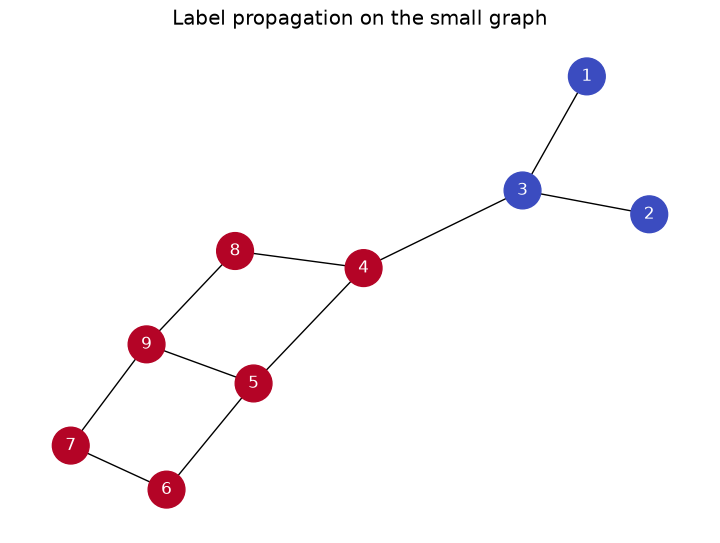

In [9]:
plt.figure(figsize=(7, 5))
example_pos = nx.spring_layout(example_graph, seed=42)
example_colors = []
for node in example_graph.nodes:
    if node in seed_labels:
        example_colors.append(seed_labels[node])
    else:
        example_colors.append(1 if Y_final[node] > 0.5 else 0)

nx.draw(
    example_graph,
    example_pos,
    with_labels=True,
    node_color=example_colors,
    cmap=plt.cm.coolwarm,
    node_size=700,
    font_color="white",
    vmin=0,
    vmax=1,
)
plt.title("Label propagation on the small graph")
plt.show()

## 3.2. Label propagation on Karate Club dataset

In [10]:
karate_seeds = {0: 0, 33: 1}
lp_Y, lp_history = binary_label_propagation(G, karate_seeds, max_iters=30, seed=0)
lp_pred = np.array([1 if lp_Y[n] > 0.5 else 0 for n in range(data.num_nodes)])

unlabeled = ~data.train_mask.numpy()
lp_unlabeled_acc = (lp_pred[unlabeled] == labels[unlabeled]).mean()
lp_full_acc = (lp_pred == labels).mean()

print(f"Iterations until last printed state: {len(lp_history) - 1}")
print(f"Predicted labels: {lp_pred.tolist()}")
print(f"True labels:      {labels.tolist()}")
print(f"Unlabeled accuracy: {lp_unlabeled_acc:.4f}")
print(f"Full-graph accuracy: {lp_full_acc:.4f}")

Iterations until last printed state: 30
Predicted labels: [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
True labels:      [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Unlabeled accuracy: 0.9688
Full-graph accuracy: 0.9706


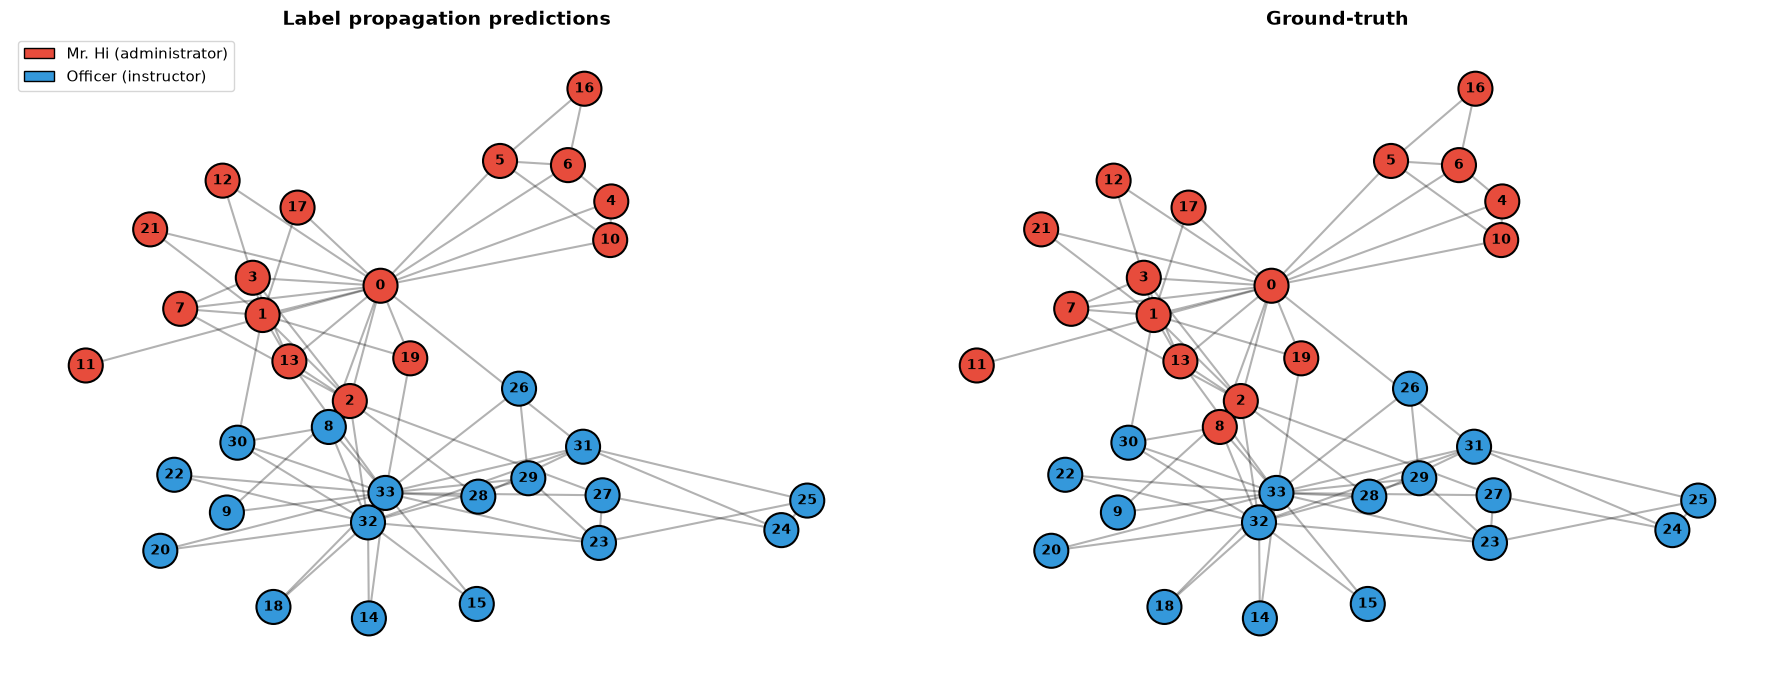

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

nx.draw_networkx_edges(G, pos, alpha=0.3, width=1.5, ax=axes[0])
nx.draw_networkx_nodes(
    G, pos, node_color=club_color_list(lp_pred), node_size=600,
    edgecolors="black", linewidths=1.5, ax=axes[0],
)
nx.draw_networkx_labels(G, pos, font_size=10, font_weight="bold", ax=axes[0])
axes[0].set_title("Label propagation predictions", fontsize=14, fontweight="bold")
axes[0].axis("off")

nx.draw_networkx_edges(G, pos, alpha=0.3, width=1.5, ax=axes[1])
nx.draw_networkx_nodes(
    G, pos, node_color=club_color_list(labels), node_size=600,
    edgecolors="black", linewidths=1.5, ax=axes[1],
)
nx.draw_networkx_labels(G, pos, font_size=10, font_weight="bold", ax=axes[1])
axes[1].set_title("Ground-truth", fontsize=14, fontweight="bold")
axes[1].axis("off")

club_legend(axes[0])
plt.tight_layout()
plt.show()

---

# 4. Message Passing

### 4.1. Core idea

At each layer (round) every node:

1. **Collects messages** from its neighbors.
2. **Aggregates** those messages with a permutation-invariant operator (sum, mean, or max).
3. **Updates** its own representation.

$$
\mathbf{h}_v^{(k)} = \mathrm{UPDATE}^{(k)}\left(
  \mathbf{h}_v^{(k-1)},\
  \mathrm{AGGREGATE}^{(k)}\left(
    \{\mathbf{m}_{u \to v}^{(k)} : u \in \mathcal{N}(v)\}
  \right)
\right)
$$

### 4.2. GCN message passing (Kipf & Welling, 2017)

$$
\mathbf{h}_v^{(k)} = \sigma\left(
  \mathbf{W}^{(k)}
  \sum_{u \in \mathcal{N}(v)\cup\{v\}}
  \frac{\mathbf{h}_u^{(k-1)}}{\sqrt{\deg(v)\,\deg(u)}}
\right)
$$

| Step | Operation | Purpose |
|------|-----------|--------|
| **Message** | $\mathbf{m}_{u\to v} = \frac{1}{\sqrt{\deg(u)\deg(v)}}\,\mathbf{h}_u$ | Neighbor prepares a normalized message |
| **Aggregate** | $\mathbf{a}_v = \sum_u \mathbf{m}_{u\to v}$ | Combine incoming messages |
| **Update** | $\mathbf{h}_v = \sigma(\mathbf{W}\,\mathbf{a}_v)$ | Linear map + nonlinearity |

## 4.3. Identity features and the normalized adjacency

In [12]:
# One-hot features make it easy to see whose information mixes into a node
num_nodes = data.num_nodes
X = torch.eye(num_nodes)

print(f"Initial feature matrix shape: {X.shape}")
print(f"Node 0 initial features (first 10 dims): {X[0, :10].tolist()}")
print(f"Node 1 initial features (first 10 dims): {X[1, :10].tolist()}")

Initial feature matrix shape: torch.Size([34, 34])
Node 0 initial features (first 10 dims): [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
Node 1 initial features (first 10 dims): [0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


In [13]:
def build_gcn_normalized_adjacency(edge_index, num_nodes):
    '''
    Return A_hat = D_tilde^{-1/2} A_tilde D_tilde^{-1/2}
    where A_tilde = A + I.
    '''
    edge_index_with_loops, _ = add_self_loops(edge_index, num_nodes=num_nodes)
    row, col = edge_index_with_loops

    deg = degree(row, num_nodes=num_nodes)
    deg_inv_sqrt = deg.pow(-0.5)
    deg_inv_sqrt[deg_inv_sqrt == float("inf")] = 0
    norm_coeffs = deg_inv_sqrt[row] * deg_inv_sqrt[col]

    A_hat = torch.zeros(num_nodes, num_nodes)
    for i in range(edge_index_with_loops.shape[1]):
        src, dst = int(row[i]), int(col[i])
        A_hat[dst, src] = norm_coeffs[i]

    return A_hat, edge_index_with_loops, deg


A_hat, edge_index_with_loops, deg = build_gcn_normalized_adjacency(
    data.edge_index, num_nodes
)

print("Normalized adjacency (A_hat) statistics:")
print(f"  Shape: {tuple(A_hat.shape)}")
print(f"  Non-zero entries: {int((A_hat != 0).sum())}")
print(f"  Row sums (first 5): {A_hat.sum(dim=1)[:5].tolist()}")

Normalized adjacency (A_hat) statistics:
  Shape: (34, 34)
  Non-zero entries: 190
  Row sums (first 5): [1.8707982301712036, 1.3267700672149658, 1.2976635694503784, 1.009562611579895, 0.8448746204376221]


## 4.4. Trace every message arriving at Node 0

In [14]:
target_node = 0
neighbors = []
for i in range(edge_index_with_loops.shape[1]):
    if int(edge_index_with_loops[1, i]) == target_node:
        neighbors.append(int(edge_index_with_loops[0, i]))

print(f"Node {target_node} receives messages from {len(neighbors)} sources:")
print(f"  Neighbors (including self-loop): {sorted(neighbors)}")
print(f"  Degree (with self-loop): {int(deg[target_node].item())}")
print()
print(f"Messages arriving at Node {target_node}:")
print("-" * 65)
print(f"{'Source':>8} | {'Norm Coeff':>12} | {'Message (non-zero idx, value)'}")
print("-" * 65)

aggregated = torch.zeros(num_nodes)
for src in sorted(neighbors):
    coeff = A_hat[target_node, src].item()
    message = coeff * X[src]
    aggregated = aggregated + message
    print(f"{src:>8} | {coeff:>12.4f} | dim {src}: {message[src].item():.4f}")

print("-" * 65)
print(f"\nAggregated features for Node {target_node} (non-zero entries):")
nonzero_indices = torch.where(aggregated != 0)[0].tolist()
for idx in nonzero_indices:
    print(f"  dim {idx}: {aggregated[idx].item():.4f} (from Node {idx})")

Node 0 receives messages from 17 sources:
  Neighbors (including self-loop): [0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 17, 19, 21, 31]
  Degree (with self-loop): 17

Messages arriving at Node 0:
-----------------------------------------------------------------
  Source |   Norm Coeff | Message (non-zero idx, value)
-----------------------------------------------------------------
       0 |       0.0588 | dim 0: 0.0588
       1 |       0.0767 | dim 1: 0.0767
       2 |       0.0731 | dim 2: 0.0731
       3 |       0.0917 | dim 3: 0.0917
       4 |       0.1213 | dim 4: 0.1213
       5 |       0.1085 | dim 5: 0.1085
       6 |       0.1085 | dim 6: 0.1085
       7 |       0.1085 | dim 7: 0.1085
       8 |       0.0990 | dim 8: 0.0990
      10 |       0.1213 | dim 10: 0.1213
      11 |       0.1715 | dim 11: 0.1715
      12 |       0.1400 | dim 12: 0.1400
      13 |       0.0990 | dim 13: 0.0990
      17 |       0.1400 | dim 17: 0.1400
      19 |       0.1213 | dim 19: 0.1213
      21 

## 4.5. Sum, mean, and max aggregation

In [15]:
def generate_messages(neighbor_features):
    '''In the basic model the message is the neighbor representation itself.'''
    return neighbor_features


def aggregate(messages, method="mean"):
    if method == "sum":
        return messages.sum(dim=0)
    if method == "mean":
        return messages.mean(dim=0)
    if method == "max":
        return messages.max(dim=0).values
    raise ValueError(f"Unknown aggregation method: {method}")


def update(self_features, aggregated, W_self, W_neigh):
    '''Combine the node state with the aggregated neighborhood, then apply ReLU.'''
    return torch.relu(self_features @ W_self + aggregated @ W_neigh)


neighbor_ids = list(G.neighbors(0))
neighbor_x = data.x[neighbor_ids]
messages = generate_messages(neighbor_x)

print("Target node: 0")
print("Neighbors of node 0:", neighbor_ids)
for method in ["sum", "mean", "max"]:
    agg = aggregate(messages, method=method)
    print(f"{method:4s} aggregation:", [round(v, 4) for v in agg[:8].tolist()])

feat_dim = data.x.size(1)
torch.manual_seed(0)
W_self = torch.randn(feat_dim, 8) * 0.1
W_neigh = torch.randn(feat_dim, 8) * 0.1
h0 = update(data.x[0], aggregate(messages, "mean"), W_self, W_neigh)
print("Updated representation of node 0:", [round(v, 4) for v in h0.tolist()])

Target node: 0
Neighbors of node 0: [1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 17, 19, 21, 31]
sum  aggregation: [0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
mean aggregation: [0.0, 0.0625, 0.0625, 0.0625, 0.0625, 0.0625, 0.0625, 0.0625]
max  aggregation: [0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
Updated representation of node 0: [0.0, 0.0, 0.0, 0.0, 0.1171, 0.0496, 0.0131, 0.0]


## 4.6. Visualize message flow

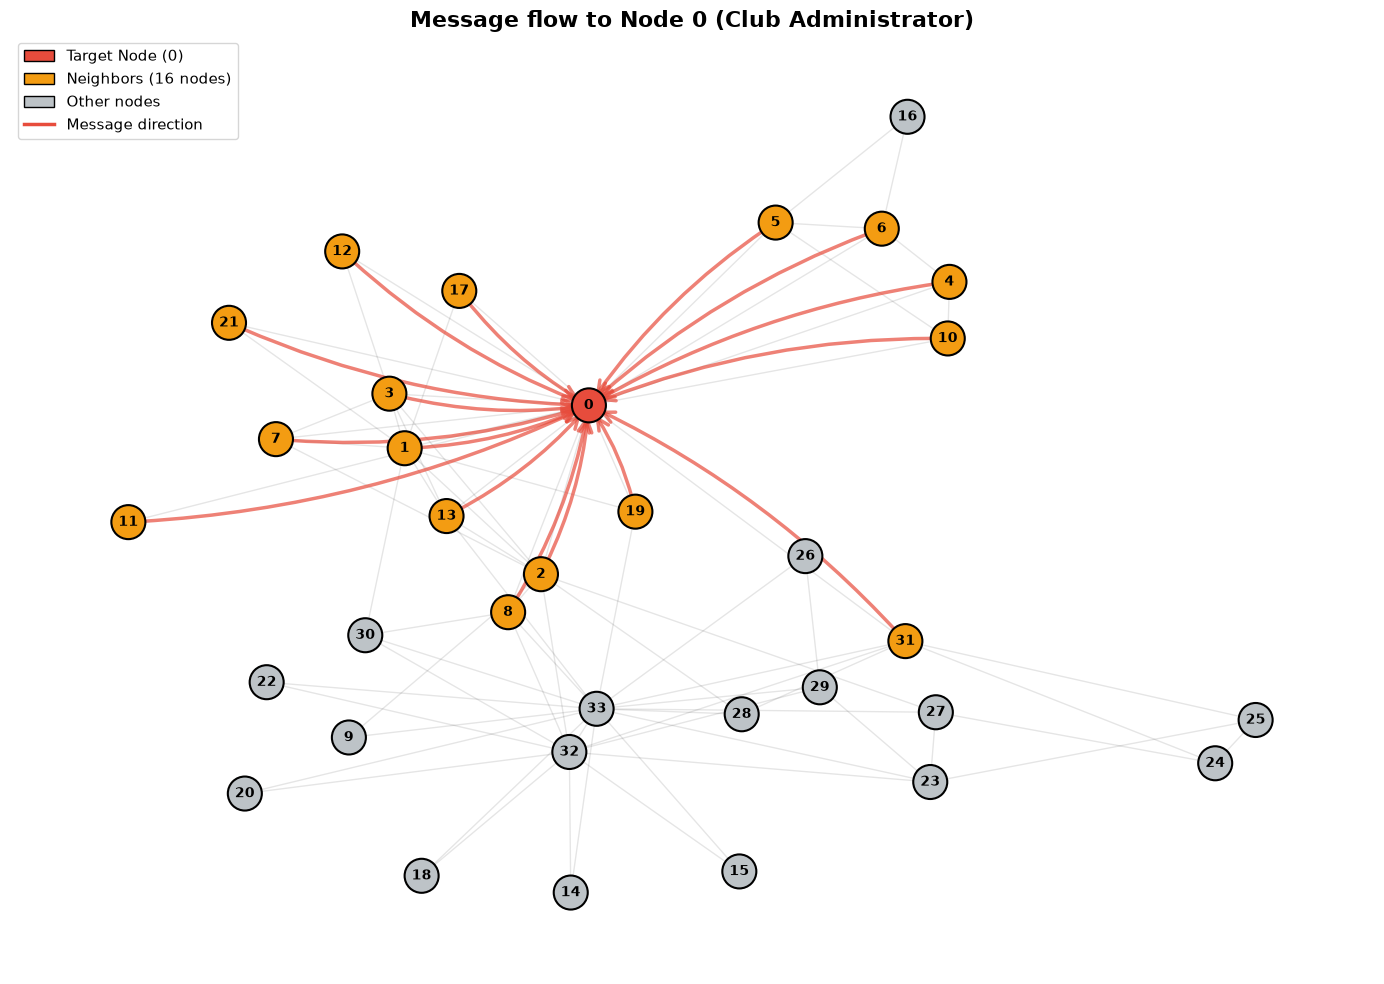

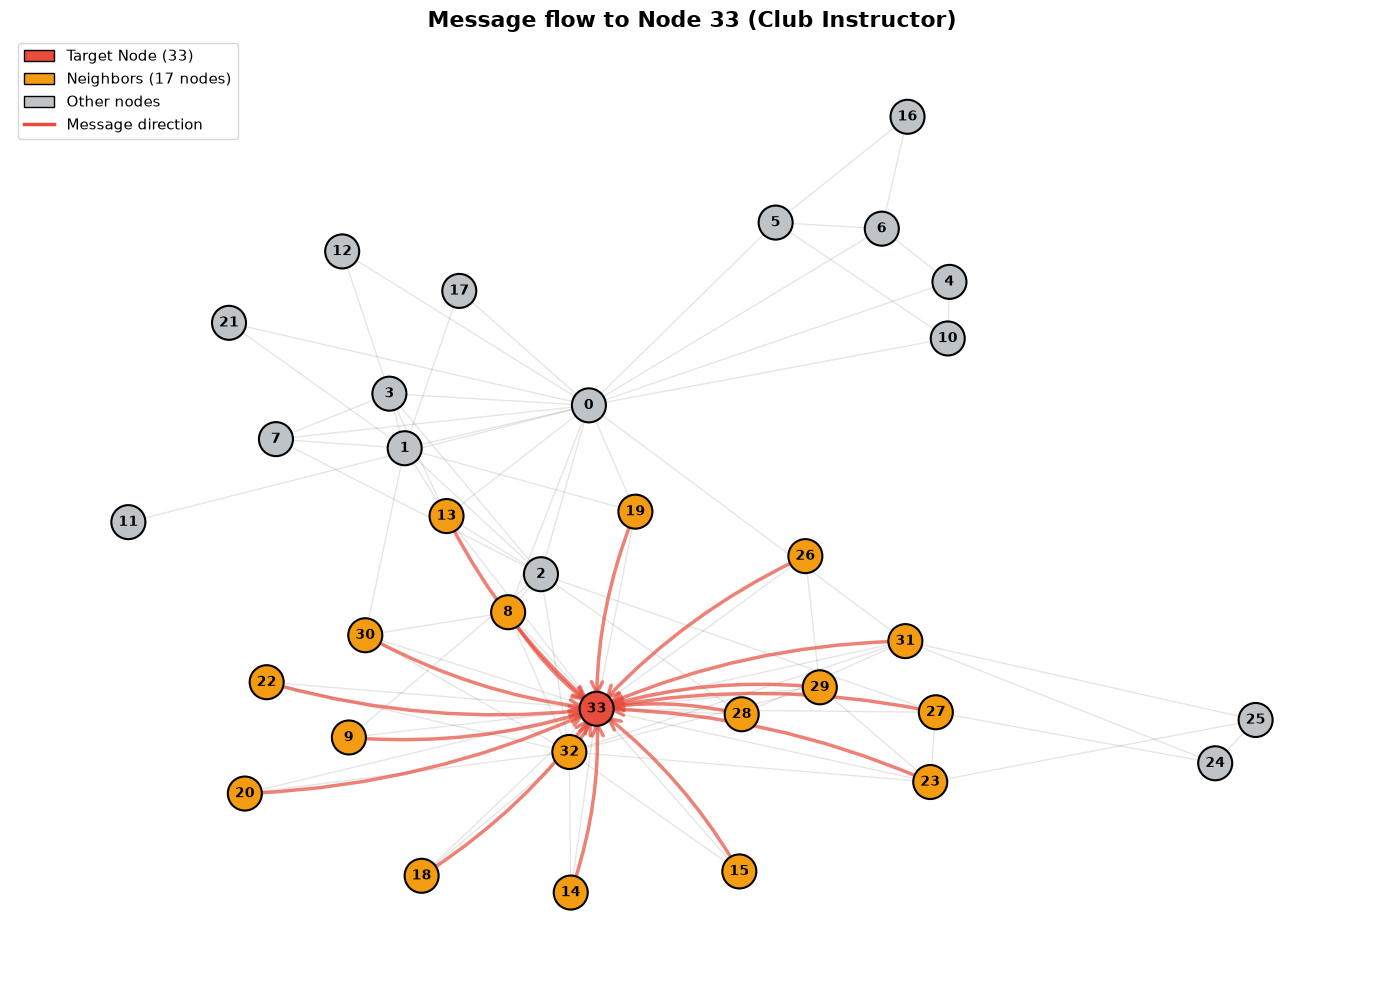

In [16]:
def visualize_message_flow(graph, layout, target_node, title):
    fig, ax = plt.subplots(1, 1, figsize=(14, 10))
    neighbors_set = set(graph.neighbors(target_node))

    node_colors = []
    for n in graph.nodes():
        if n == target_node:
            node_colors.append("#E74C3C")
        elif n in neighbors_set:
            node_colors.append("#F39C12")
        else:
            node_colors.append("#BDC3C7")

    nx.draw_networkx_edges(graph, layout, alpha=0.1, width=1, ax=ax)
    nx.draw_networkx_edges(
        graph,
        layout,
        edgelist=[(n, target_node) for n in neighbors_set],
        edge_color="#E74C3C",
        width=2.5,
        alpha=0.7,
        arrows=True,
        arrowstyle="->",
        arrowsize=20,
        connectionstyle="arc3,rad=0.1",
        ax=ax,
    )
    nx.draw_networkx_nodes(
        graph, layout, node_color=node_colors, node_size=600,
        edgecolors="black", linewidths=1.5, ax=ax,
    )
    nx.draw_networkx_labels(graph, layout, font_size=10, font_weight="bold", ax=ax)

    ax.legend(
        handles=[
            mpatches.Patch(facecolor="#E74C3C", edgecolor="black", label=f"Target Node ({target_node})"),
            mpatches.Patch(facecolor="#F39C12", edgecolor="black", label=f"Neighbors ({len(neighbors_set)} nodes)"),
            mpatches.Patch(facecolor="#BDC3C7", edgecolor="black", label="Other nodes"),
            Line2D([0], [0], color="#E74C3C", linewidth=2.5, label="Message direction"),
        ],
        loc="upper left",
        fontsize=11,
    )
    ax.set_title(title, fontsize=16, fontweight="bold")
    ax.axis("off")
    plt.tight_layout()
    plt.show()


visualize_message_flow(G, pos, 0, "Message flow to Node 0 (Club Administrator)")
visualize_message_flow(G, pos, 33, "Message flow to Node 33 (Club Instructor)")

## 4.7. Receptive field growth

- After **1 layer** a node sees its 1-hop neighbors.
- After **2 layers** it sees the 2-hop neighborhood.
- After **k layers** it sees its *k*-hop neighborhood.

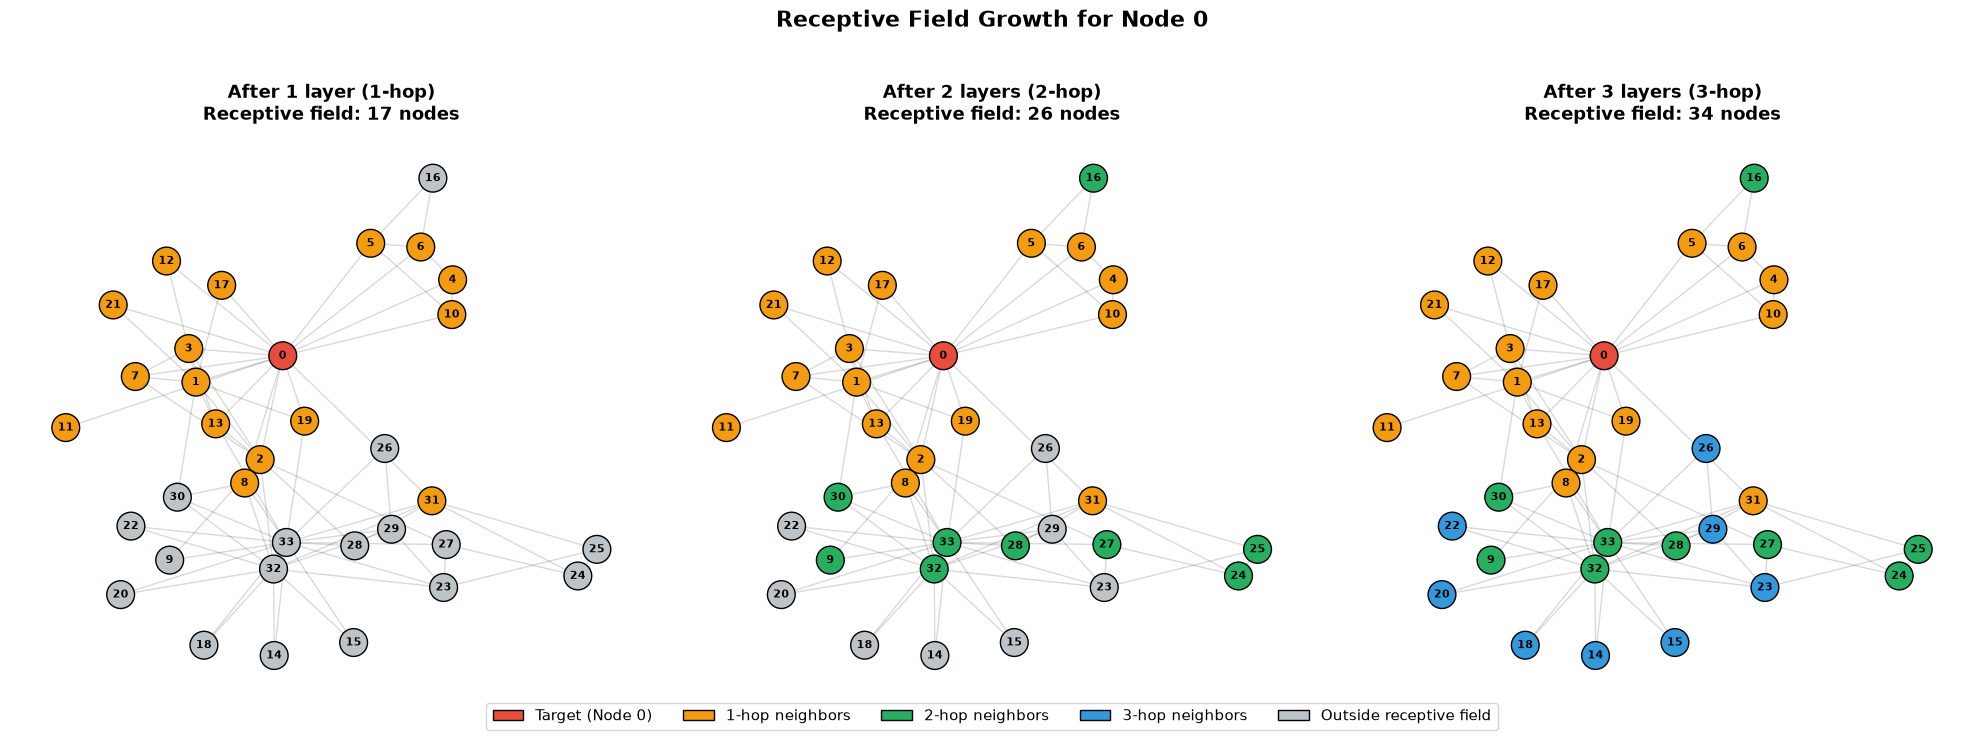

In [17]:
def get_k_hop_neighbors(graph, target_node, k):
    neighbors_by_hop = {0: {target_node}}
    all_neighbors = {target_node}
    for hop in range(1, k + 1):
        new_neighbors = set()
        for node in neighbors_by_hop[hop - 1]:
            for neighbor in graph.neighbors(node):
                if neighbor not in all_neighbors:
                    new_neighbors.add(neighbor)
        neighbors_by_hop[hop] = new_neighbors
        all_neighbors |= new_neighbors
    return neighbors_by_hop, all_neighbors


target_node = 0
max_hops = 3
hop_colors = {0: "#E74C3C", 1: "#F39C12", 2: "#27AE60", 3: "#3498DB"}

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
for k in range(1, max_hops + 1):
    ax = axes[k - 1]
    neighbors_by_hop, all_neighbors = get_k_hop_neighbors(G, target_node, k)
    node_colors = []
    for n in G.nodes():
        colored = False
        for hop in range(k + 1):
            if n in neighbors_by_hop.get(hop, set()):
                node_colors.append(hop_colors[hop])
                colored = True
                break
        if not colored:
            node_colors.append("#BDC3C7")
    nx.draw_networkx_edges(G, pos, alpha=0.15, width=1, ax=ax)
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=400,
                           edgecolors="black", linewidths=1, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=8, font_weight="bold", ax=ax)
    ax.set_title(
        f"After {k} layer{'s' if k > 1 else ''} ({k}-hop)\nReceptive field: {len(all_neighbors)} nodes",
        fontsize=13,
        fontweight="bold",
    )
    ax.axis("off")

fig.legend(
    handles=[
        mpatches.Patch(facecolor=hop_colors[0], edgecolor="black", label=f"Target (Node {target_node})"),
        mpatches.Patch(facecolor=hop_colors[1], edgecolor="black", label="1-hop neighbors"),
        mpatches.Patch(facecolor=hop_colors[2], edgecolor="black", label="2-hop neighbors"),
        mpatches.Patch(facecolor=hop_colors[3], edgecolor="black", label="3-hop neighbors"),
        mpatches.Patch(facecolor="#BDC3C7", edgecolor="black", label="Outside receptive field"),
    ],
    loc="lower center",
    ncol=5,
    fontsize=11,
    bbox_to_anchor=(0.5, -0.02),
)
fig.suptitle(f"Receptive Field Growth for Node {target_node}", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 4.8. A full round of message passing for every node

In [18]:
def manual_message_passing(X, A_hat, W=None, activation=True):
    '''
    One GCN-style round:
      1. AGGREGATE: H = A_hat @ X
      2. TRANSFORM: H = H @ W
      3. ACTIVATE:  H = ReLU(H)
    '''
    H = A_hat @ X
    print(f"  After AGGREGATE: shape = {tuple(H.shape)}")
    if W is not None:
        H = H @ W
        print(f"  After TRANSFORM: shape = {tuple(H.shape)}")
    if activation:
        H = F.relu(H)
        print(f"  After ACTIVATE:  shape = {tuple(H.shape)}")
    return H


X0 = torch.eye(num_nodes)
torch.manual_seed(42)
W1 = torch.randn(num_nodes, 16) * 0.1

print("Round 1 of Message Passing:")
print("=" * 50)
X1 = manual_message_passing(X0, A_hat, W1, activation=True)
print(f"\nNode 0  new embedding: {X1[0, :8].detach().numpy().round(4)}")
print(f"Node 33 new embedding: {X1[33, :8].detach().numpy().round(4)}")

Round 1 of Message Passing:
  After AGGREGATE: shape = (34, 34)
  After TRANSFORM: shape = (34, 16)
  After ACTIVATE:  shape = (34, 16)

Node 0  new embedding: [0.0023 0.     0.     0.     0.     0.     0.     0.    ]
Node 33 new embedding: [0.0213 0.0067 0.0157 0.     0.     0.     0.     0.0291]


In [19]:
# Run 3 rounds: 34 -> 16 -> 8 -> 4
torch.manual_seed(42)
X_current = torch.eye(num_nodes)
history = [X_current.detach().clone()]
dims = [34, 16, 8, 4]
weights = [torch.randn(dims[i], dims[i + 1]) * 0.1 for i in range(3)]

for layer in range(3):
    print(f"\n--- Layer {layer + 1} ---")
    X_current = manual_message_passing(
        X_current, A_hat, weights[layer], activation=(layer < 2)
    )
    history.append(X_current.detach().clone())

print("\nRepresentation dimensions at each layer:")
for i, h in enumerate(history):
    print(f"  Layer {i}: {tuple(h.shape)}")


--- Layer 1 ---
  After AGGREGATE: shape = (34, 34)
  After TRANSFORM: shape = (34, 16)
  After ACTIVATE:  shape = (34, 16)

--- Layer 2 ---
  After AGGREGATE: shape = (34, 16)
  After TRANSFORM: shape = (34, 8)
  After ACTIVATE:  shape = (34, 8)

--- Layer 3 ---
  After AGGREGATE: shape = (34, 8)
  After TRANSFORM: shape = (34, 4)

Representation dimensions at each layer:
  Layer 0: (34, 34)
  Layer 1: (34, 16)
  Layer 2: (34, 8)
  Layer 3: (34, 4)


## 4.9. How representations change across layers

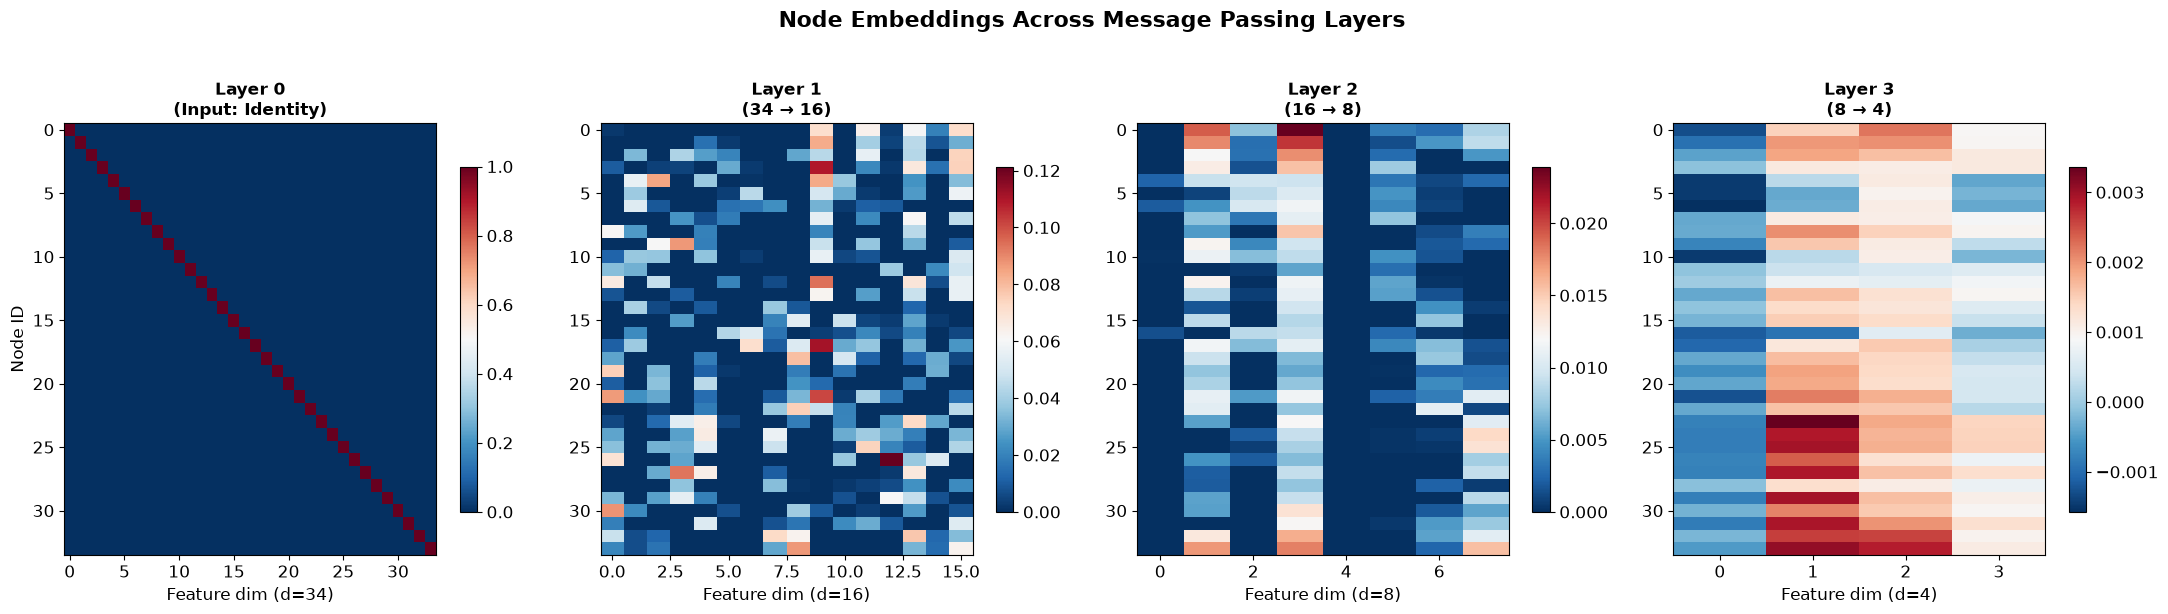

In [20]:
fig, axes = plt.subplots(1, 4, figsize=(22, 6))
layer_names = ["Layer 0\n(Input: Identity)", "Layer 1\n(34 → 16)", "Layer 2\n(16 → 8)", "Layer 3\n(8 → 4)"]
for i, (h, name) in enumerate(zip(history, layer_names)):
    im = axes[i].imshow(h.numpy(), cmap="RdBu_r", aspect="auto", interpolation="none")
    axes[i].set_title(name, fontsize=12, fontweight="bold")
    axes[i].set_ylabel("Node ID" if i == 0 else "")
    axes[i].set_xlabel(f"Feature dim (d={h.shape[1]})")
    plt.colorbar(im, ax=axes[i], shrink=0.8)
fig.suptitle("Node Embeddings Across Message Passing Layers", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 4.10. Node similarity before and after message passing

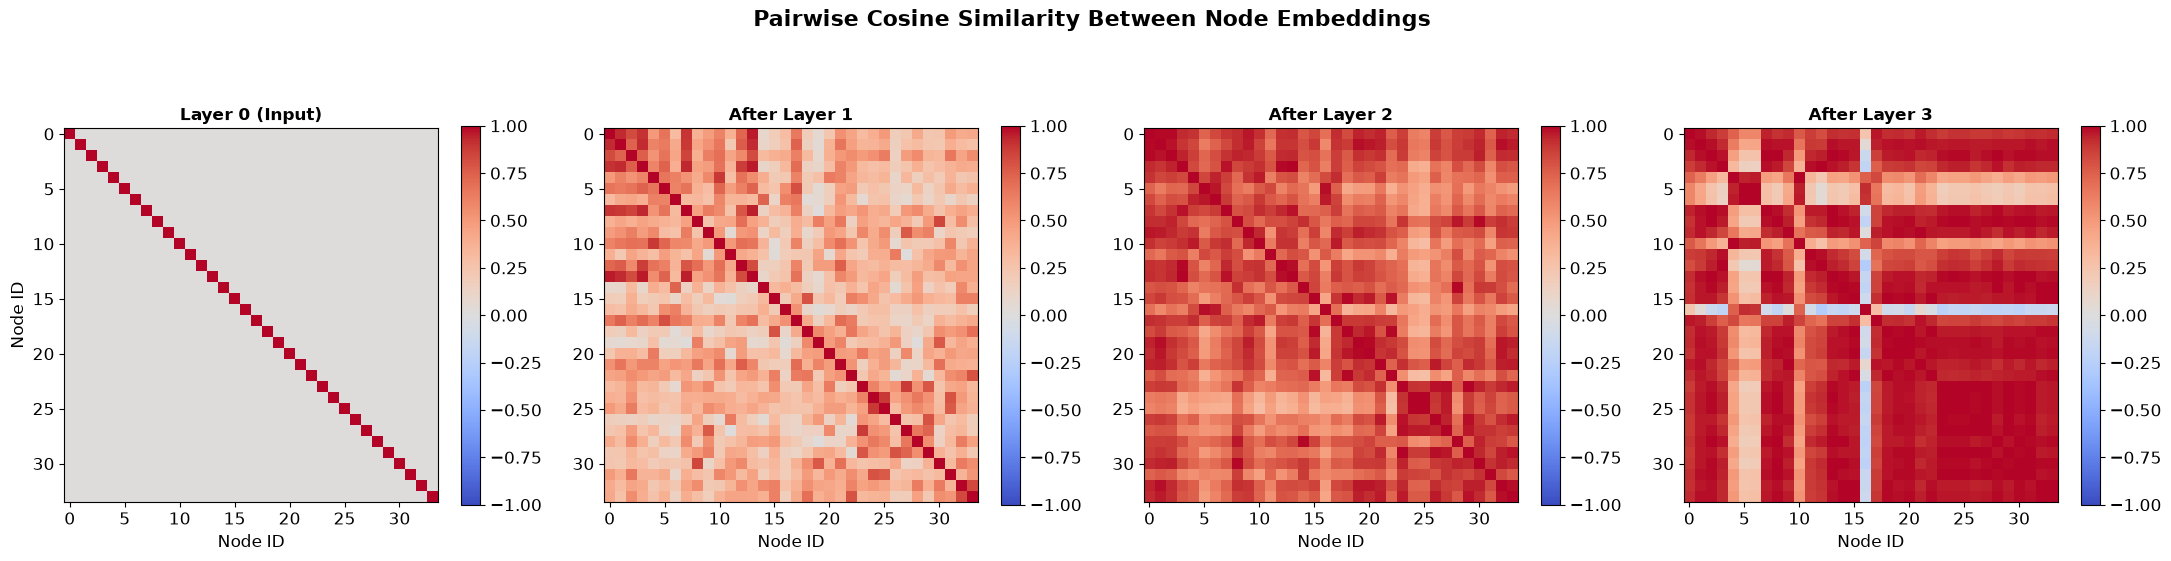

In [21]:
def cosine_similarity_matrix(H):
    H_norm = F.normalize(H, p=2, dim=1)
    return (H_norm @ H_norm.T).numpy()


fig, axes = plt.subplots(1, 4, figsize=(22, 5.5))
layer_names = ["Layer 0 (Input)", "After Layer 1", "After Layer 2", "After Layer 3"]
for i, (h, name) in enumerate(zip(history, layer_names)):
    im = axes[i].imshow(cosine_similarity_matrix(h), cmap="coolwarm", vmin=-1, vmax=1, interpolation="none")
    axes[i].set_title(name, fontsize=12, fontweight="bold")
    axes[i].set_xlabel("Node ID")
    axes[i].set_ylabel("Node ID" if i == 0 else "")
    plt.colorbar(im, ax=axes[i], shrink=0.8)
fig.suptitle("Pairwise Cosine Similarity Between Node Embeddings", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

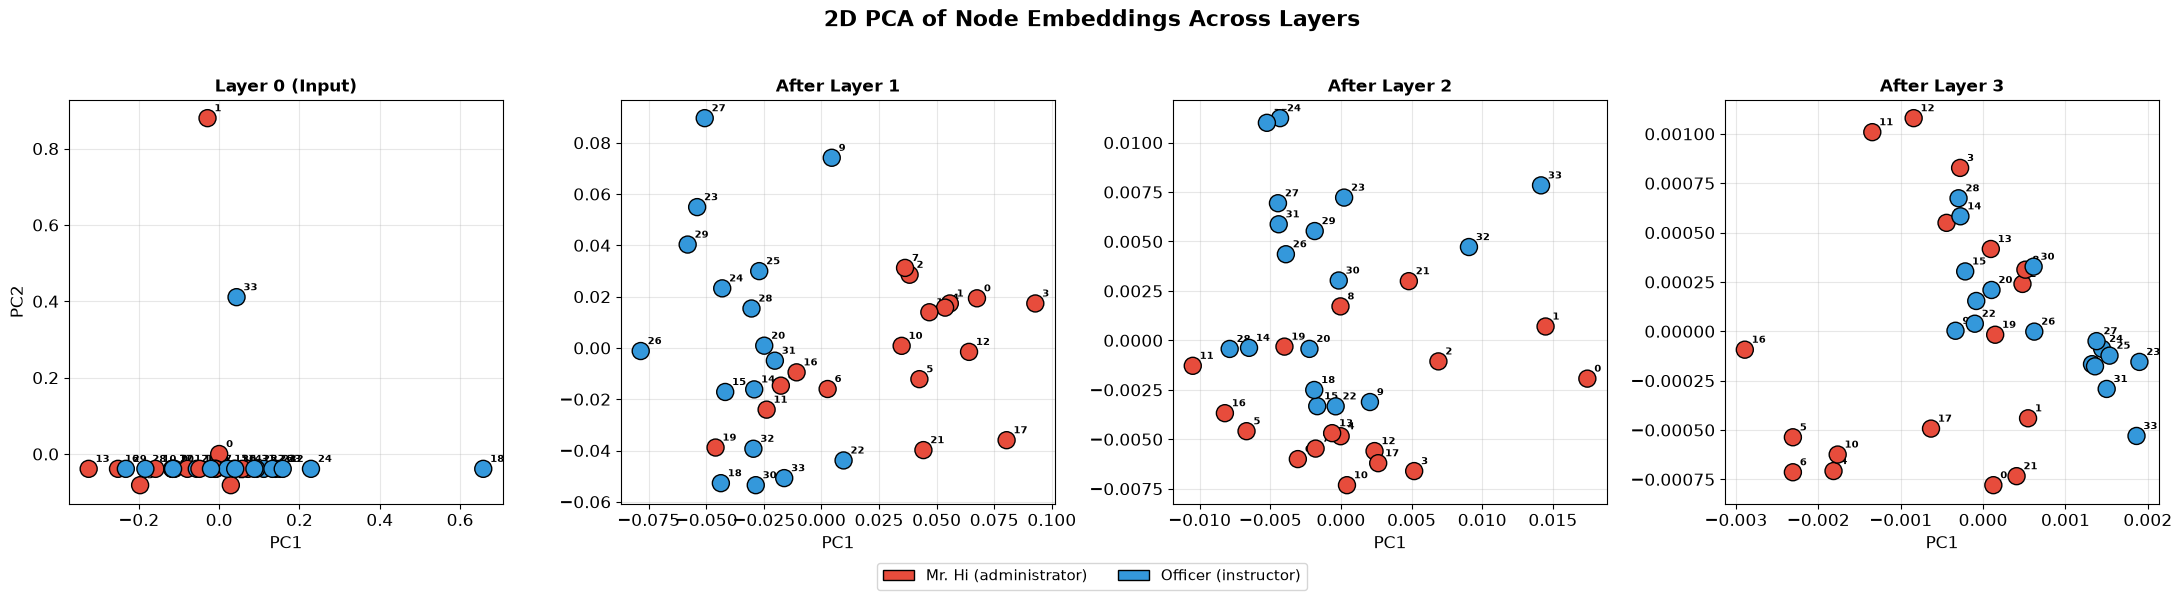

In [22]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5.5))
community_colors = club_color_list(labels)

for i, (h, name) in enumerate(zip(history, layer_names)):
    h_np = h.numpy()
    h_2d = PCA(n_components=2).fit_transform(h_np) if h_np.shape[1] >= 2 else h_np
    axes[i].scatter(h_2d[:, 0], h_2d[:, 1], c=community_colors, s=150, edgecolors="black", linewidths=1, zorder=5)
    for j in range(num_nodes):
        axes[i].annotate(str(j), (h_2d[j, 0], h_2d[j, 1]), textcoords="offset points", xytext=(5, 5), fontsize=7, fontweight="bold")
    axes[i].set_title(name, fontsize=12, fontweight="bold")
    axes[i].set_xlabel("PC1")
    axes[i].set_ylabel("PC2" if i == 0 else "")
    axes[i].grid(True, alpha=0.3)

fig.legend(
    handles=[
        mpatches.Patch(facecolor=CLUB_COLORS[i], edgecolor="black", label=CLUB_NAMES[i])
        for i in range(num_classes)
    ],
    loc="lower center",
    ncol=2,
    fontsize=11,
    bbox_to_anchor=(0.5, -0.05),
)
fig.suptitle("2D PCA of Node Embeddings Across Layers", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---

# 5. Training a basic GNN

In [23]:
class MeanAggregationLayer(nn.Module):
    '''Average neighbor messages, then combine with a linear map + ReLU.'''

    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.W_self = nn.Linear(in_dim, out_dim, bias=False)
        self.W_neigh = nn.Linear(in_dim, out_dim, bias=False)

    def forward(self, x, adj):
        degree = adj.sum(dim=1, keepdim=True).clamp(min=1.0)
        aggregated = (adj @ x) / degree
        return torch.relu(self.W_self(x) + self.W_neigh(aggregated))


class BasicGNN(nn.Module):
    '''Two-layer mean-aggregation GNN for node classification.'''

    def __init__(self, in_dim, hidden_dim, num_classes):
        super().__init__()
        self.layer1 = MeanAggregationLayer(in_dim, hidden_dim)
        self.layer2 = MeanAggregationLayer(hidden_dim, hidden_dim)
        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, x, adj, return_embeddings=False):
        h = self.layer1(x, adj)
        h = self.layer2(h, adj)
        if return_embeddings:
            return h
        return self.classifier(h)


adj = to_dense_adj(data.edge_index, max_num_nodes=data.num_nodes)[0]
print("Mean-aggregation adjacency shape:", tuple(adj.shape))

Mean-aggregation adjacency shape: (34, 34)


In [24]:
def accuracy_from_logits(logits, y, train_mask):
    pred = logits.argmax(dim=1)
    train_acc = (pred[train_mask] == y[train_mask]).float().mean().item()
    full_acc = (pred == y).float().mean().item()
    return pred, train_acc, full_acc


def train_dense_model(model, x, support, y, train_mask, epochs=300, lr=0.01, name="model"):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=5e-4)
    history_loss, history_train, history_full = [], [], []

    print(f"Training {name}")
    print("=" * 60)
    for epoch in range(1, epochs + 1):
        model.train()
        optimizer.zero_grad()
        logits = model(x, support)
        loss = F.cross_entropy(logits[train_mask], y[train_mask])
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            logits_eval = model(x, support)
            _, train_acc, full_acc = accuracy_from_logits(logits_eval, y, train_mask)

        history_loss.append(loss.item())
        history_train.append(train_acc)
        history_full.append(full_acc)

        if epoch % 20 == 0 or epoch == 1:
            print(
                f"Epoch {epoch:03d}/{epochs} | loss={loss.item():.4f} "
                f"| train acc={train_acc:.4f} | full-graph acc={full_acc:.4f}"
            )

    print("=" * 60)
    return history_loss, history_train, history_full


torch.manual_seed(42)
basic_gnn = BasicGNN(data.x.size(1), hidden_dim=16, num_classes=num_classes)
basic_losses, basic_train_accs, basic_full_accs = train_dense_model(
    basic_gnn, data.x, adj, data.y, data.train_mask, name="the basic mean-aggregation GNN"
)

Training the basic mean-aggregation GNN
Epoch 001/300 | loss=0.6926 | train acc=0.5000 | full-graph acc=0.5000
Epoch 020/300 | loss=0.1164 | train acc=1.0000 | full-graph acc=0.8824
Epoch 040/300 | loss=0.0002 | train acc=1.0000 | full-graph acc=0.9706
Epoch 060/300 | loss=0.0001 | train acc=1.0000 | full-graph acc=0.9706
Epoch 080/300 | loss=0.0001 | train acc=1.0000 | full-graph acc=0.9706
Epoch 100/300 | loss=0.0003 | train acc=1.0000 | full-graph acc=0.9706
Epoch 120/300 | loss=0.0005 | train acc=1.0000 | full-graph acc=0.9706
Epoch 140/300 | loss=0.0007 | train acc=1.0000 | full-graph acc=0.9706
Epoch 160/300 | loss=0.0005 | train acc=1.0000 | full-graph acc=0.9706
Epoch 180/300 | loss=0.0006 | train acc=1.0000 | full-graph acc=0.9706
Epoch 200/300 | loss=0.0006 | train acc=1.0000 | full-graph acc=0.9706
Epoch 220/300 | loss=0.0006 | train acc=1.0000 | full-graph acc=0.9706
Epoch 240/300 | loss=0.0006 | train acc=1.0000 | full-graph acc=0.9706
Epoch 260/300 | loss=0.0006 | train a

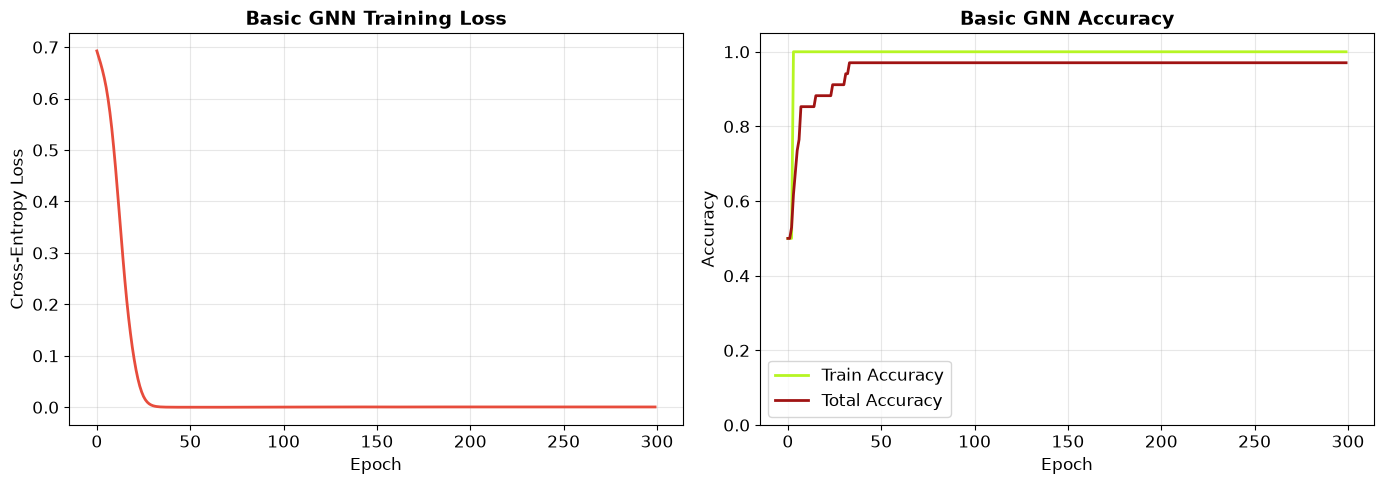

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(basic_losses, color="#E74C3C", linewidth=2)
axes[0].set_title("Basic GNN Training Loss", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].grid(True, alpha=0.3)

axes[1].plot(basic_train_accs, color="#B6F523", linewidth=2, label="Train Accuracy")
axes[1].plot(basic_full_accs, color="#A01313", linewidth=2, label="Total Accuracy")
axes[1].set_title("Basic GNN Accuracy", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend(fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 1.05])
plt.tight_layout()
plt.show()

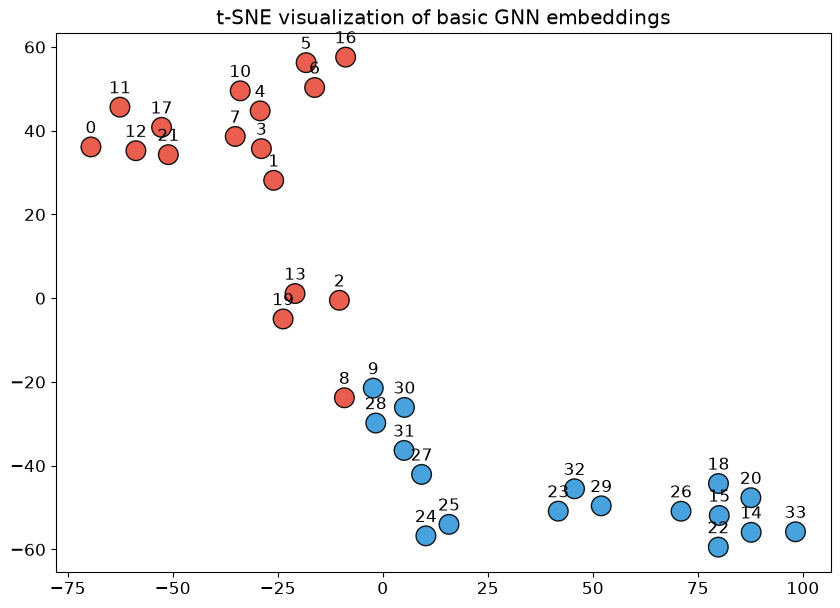

In [26]:
basic_gnn.eval()
with torch.no_grad():
    basic_embeddings = basic_gnn(data.x, adj, return_embeddings=True).cpu().numpy()

tsne = TSNE(n_components=2, random_state=42, perplexity=5)
basic_2d = tsne.fit_transform(basic_embeddings)

plt.figure(figsize=(10, 7))
plt.scatter(basic_2d[:, 0], basic_2d[:, 1], s=200, c=club_color_list(labels), edgecolors="black", alpha=0.9)
for i in range(num_nodes):
    plt.annotate(str(i), (basic_2d[i, 0], basic_2d[i, 1]), textcoords="offset points", xytext=(0, 10), ha="center")
plt.title("t-SNE visualization of basic GNN embeddings")
plt.show()

---

# 6. Graph Convolutional Network

GCN refines mean aggregation with **symmetric degree normalization** and a **shared** weight for a node and its neighbors.

**Per-node form**

$$
\mathbf{h}_v^{k} = \sigma\left(
  \mathbf{W}^{k}
  \sum_{u \in \mathcal{N}(v)\cup\{v\}}
  \frac{\mathbf{h}_u^{k-1}}{\sqrt{|\mathcal{N}(u)|\,|\mathcal{N}(v)|}}
\right)
$$

**Batch / matrix form**

$$
\mathbf{H}^{k+1} = \sigma\left(\tilde{\mathbf{D}}^{-1/2}\tilde{\mathbf{A}}\tilde{\mathbf{D}}^{-1/2}\mathbf{H}^{k}\mathbf{W}^{k}\right),
\qquad \tilde{\mathbf{A}} = \mathbf{A}+\mathbf{I}
$$

## 6.1. GCN



A scratch GCN is a GCN implemented directly with PyTorch tensor operations, without using PyG's built-in `GCNConv` or `MessagePassing` abstractions. In this section, `ScratchGCN` makes the main computation explicit:

$$
\mathbf{H}' = \sigma\left(\hat{\mathbf{A}}\,\mathbf{H}\,\mathbf{W}\right)
$$

Here, $\hat{\mathbf{A}}$ is the normalized adjacency matrix with self-loops, $\mathbf{H}$ contains node representations, $\mathbf{W}$ is a learnable weight matrix, and $\sigma$ is the ReLU activation. This implementation is useful for understanding the core mathematics and data flow of a GCN.

In [27]:
class GCNLayer(nn.Module):
    '''One layer: H' = activation(A_hat H W).'''

    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.W = nn.Linear(in_dim, out_dim, bias=False)

    def forward(self, H, A_hat, activation=True):
        out = A_hat @ self.W(H)
        return torch.relu(out) if activation else out


class ScratchGCN(nn.Module):
    '''Two-layer GCN.'''

    def __init__(self, in_dim, hidden_dim, num_classes):
        super().__init__()
        self.conv1 = GCNLayer(in_dim, hidden_dim)
        self.conv2 = GCNLayer(hidden_dim, num_classes)

    def forward(self, x, A_hat, return_embeddings=False):
        h = self.conv1(x, A_hat, activation=True)
        if return_embeddings:
            return h
        return self.conv2(h, A_hat, activation=False)


torch.manual_seed(42)
scratch_gcn = ScratchGCN(data.x.size(1), hidden_dim=16, num_classes=num_classes)
gcn_losses, gcn_train_accs, gcn_full_accs = train_dense_model(
    scratch_gcn, data.x, A_hat, data.y, data.train_mask, name="the scratch GCN"
)

Training the scratch GCN
Epoch 001/300 | loss=0.6926 | train acc=0.5000 | full-graph acc=0.5294
Epoch 020/300 | loss=0.3983 | train acc=1.0000 | full-graph acc=1.0000
Epoch 040/300 | loss=0.0887 | train acc=1.0000 | full-graph acc=0.9706
Epoch 060/300 | loss=0.0157 | train acc=1.0000 | full-graph acc=0.9706
Epoch 080/300 | loss=0.0071 | train acc=1.0000 | full-graph acc=0.9706
Epoch 100/300 | loss=0.0052 | train acc=1.0000 | full-graph acc=0.9706
Epoch 120/300 | loss=0.0045 | train acc=1.0000 | full-graph acc=0.9706
Epoch 140/300 | loss=0.0041 | train acc=1.0000 | full-graph acc=0.9706
Epoch 160/300 | loss=0.0039 | train acc=1.0000 | full-graph acc=0.9706
Epoch 180/300 | loss=0.0037 | train acc=1.0000 | full-graph acc=0.9706
Epoch 200/300 | loss=0.0035 | train acc=1.0000 | full-graph acc=0.9706
Epoch 220/300 | loss=0.0034 | train acc=1.0000 | full-graph acc=0.9706
Epoch 240/300 | loss=0.0033 | train acc=1.0000 | full-graph acc=0.9706
Epoch 260/300 | loss=0.0032 | train acc=1.0000 | ful

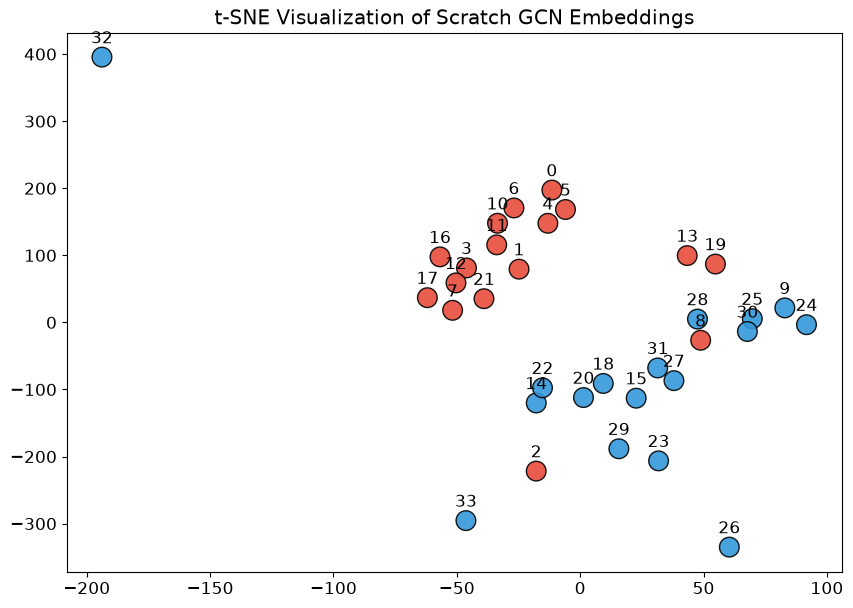

In [32]:
# t-SNE of the trained scratch GCN hidden embeddings
scratch_gcn.eval()
with torch.no_grad():
    gcn_embeddings = scratch_gcn(data.x, A_hat, return_embeddings=True).cpu().numpy()
    gcn_logits = scratch_gcn(data.x, A_hat)
    gcn_pred = gcn_logits.argmax(dim=1).cpu().numpy()

tsne = TSNE(n_components=2, random_state=42, perplexity=5)
gcn_2d = tsne.fit_transform(gcn_embeddings)

plt.figure(figsize=(10, 7))
plt.scatter(gcn_2d[:, 0], gcn_2d[:, 1], s=200, c=club_color_list(labels), edgecolors="black", alpha=0.9)
for i in range(num_nodes):
    plt.annotate(str(i), (gcn_2d[i, 0], gcn_2d[i, 1]), textcoords="offset points", xytext=(0, 10), ha="center")
plt.title("t-SNE Visualization of Scratch GCN Embeddings")
plt.show()

## 6.2. The GCN built from PyG MessagePassing layer

`CustomGCNConv` is a GCN layer built with PyG's `MessagePassing` base class. It implements the same normalized graph convolution as the scratch GCN, but expresses the computation through PyG's message-passing workflow:

1. `forward()` adds self-loops, applies the learnable linear transformation, computes degree-based normalization, and calls `propagate()`.
2. `message()` sends each source-node representation scaled by its normalization coefficient.
3. `aggr="add"` sums the incoming messages at each destination node.

This custom GCN shows how the mathematical operation can be implemented using PyG's reusable graph-processing abstraction, while keeping the message and aggregation steps visible. `KarateClubGNN` then stacks two custom layers for node classification.

In [28]:
class CustomGCNConv(MessagePassing):
    '''
    GCN layer on top of PyG MessagePassing.

    h_v = W * SUM_{u in N(v) U {v}} (1/sqrt(deg(v) deg(u))) * h_u
    '''

    def __init__(self, in_channels, out_channels):
        super().__init__(aggr="add")
        self.lin = nn.Linear(in_channels, out_channels, bias=False)
        self.bias = nn.Parameter(torch.zeros(out_channels))
        self.reset_parameters()

    def reset_parameters(self):
        self.lin.reset_parameters()
        self.bias.data.zero_()

    def forward(self, x, edge_index):
        # Add self-loops so each node also keeps its own features
        edge_index, _ = add_self_loops(edge_index, num_nodes=x.size(0))

        # Shared linear transform, then degree-normalized messages
        x = self.lin(x)
        row, col = edge_index
        deg = degree(col, x.size(0), dtype=x.dtype)
        deg_inv_sqrt = deg.pow(-0.5)
        deg_inv_sqrt[deg_inv_sqrt == float("inf")] = 0
        norm = deg_inv_sqrt[row] * deg_inv_sqrt[col]

        out = self.propagate(edge_index, x=x, norm=norm)
        return out + self.bias

    def message(self, x_j, norm):
        # x_j is the source-node feature on each edge
        return norm.view(-1, 1) * x_j


print("Custom GCN layer defined.")
print("  forward()  orchestrates self-loops, normalization, and propagate()")
print("  message()  sends norm * x_j")
print('  aggregate  is sum because aggr="add"')

Custom GCN layer defined.
  forward()  orchestrates self-loops, normalization, and propagate()
  message()  sends norm * x_j
  aggregate  is sum because aggr="add"


In [29]:
class KarateClubGNN(nn.Module):
    '''
    2-layer GNN for Karate Club classification.

    Input (34) -> GCN (16) -> ReLU -> Dropout -> GCN (2)
    '''

    def __init__(self, num_features, num_classes, hidden_dim=16):
        super().__init__()
        self.conv1 = CustomGCNConv(num_features, hidden_dim)
        self.conv2 = CustomGCNConv(hidden_dim, num_classes)
        self.dropout = nn.Dropout(p=0.5)

    def forward(self, x, edge_index, return_hidden=False):
        h = self.conv1(x, edge_index)
        h = F.relu(h)
        h = self.dropout(h)
        logits = self.conv2(h, edge_index)
        if return_hidden:
            return h, logits
        return logits


def train_sparse_model(model, data, epochs=300, lr=0.01, name="model"):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=5e-4)
    history_loss, history_train, history_full = [], [], []
    snapshots = {}

    print(f"Training {name}")
    print("=" * 60)
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        logits = model(data.x, data.edge_index)
        loss = F.cross_entropy(logits[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            hidden, logits_eval = model(data.x, data.edge_index, return_hidden=True)
            _, train_acc, full_acc = accuracy_from_logits(logits_eval, data.y, data.train_mask)

        history_loss.append(loss.item())
        history_train.append(train_acc)
        history_full.append(full_acc)

        if epoch in [0, 10, 50, 100, 199, 299]:
            snapshots[epoch] = hidden.detach().clone()

        if (epoch + 1) % 20 == 0:
            print(
                f"Epoch {epoch + 1:3d}/{epochs} | Loss: {loss.item():.4f} | "
                f"Train Acc: {train_acc:.4f} | Total Acc: {full_acc:.4f}"
            )

    print("=" * 60)
    return history_loss, history_train, history_full, snapshots


torch.manual_seed(42)
custom_model = KarateClubGNN(data.num_node_features, num_classes)
custom_losses, custom_train_accs, custom_full_accs, embedding_snapshots = train_sparse_model(
    custom_model, data, name="the custom MessagePassing GCN"
)
print(f"Total parameters: {sum(p.numel() for p in custom_model.parameters())}")

Training the custom MessagePassing GCN


Epoch  20/300 | Loss: 0.2244 | Train Acc: 1.0000 | Total Acc: 0.9706
Epoch  40/300 | Loss: 0.0162 | Train Acc: 1.0000 | Total Acc: 0.9412
Epoch  60/300 | Loss: 0.0041 | Train Acc: 1.0000 | Total Acc: 0.9412
Epoch  80/300 | Loss: 0.0029 | Train Acc: 1.0000 | Total Acc: 0.9412
Epoch 100/300 | Loss: 0.0012 | Train Acc: 1.0000 | Total Acc: 0.9412
Epoch 120/300 | Loss: 0.0060 | Train Acc: 1.0000 | Total Acc: 0.9412
Epoch 140/300 | Loss: 0.0009 | Train Acc: 1.0000 | Total Acc: 0.9412
Epoch 160/300 | Loss: 0.0010 | Train Acc: 1.0000 | Total Acc: 0.9706
Epoch 180/300 | Loss: 0.0015 | Train Acc: 1.0000 | Total Acc: 0.9706
Epoch 200/300 | Loss: 0.0013 | Train Acc: 1.0000 | Total Acc: 0.9706
Epoch 220/300 | Loss: 0.0007 | Train Acc: 1.0000 | Total Acc: 0.9412
Epoch 240/300 | Loss: 0.0032 | Train Acc: 1.0000 | Total Acc: 0.9412
Epoch 260/300 | Loss: 0.0023 | Train Acc: 1.0000 | Total Acc: 0.9706
Epoch 280/300 | Loss: 0.0016 | Train Acc: 1.0000 | Total Acc: 0.9706
Epoch 300/300 | Loss: 0.0016 | Tra

## 6.3. Training curves and embedding evolution

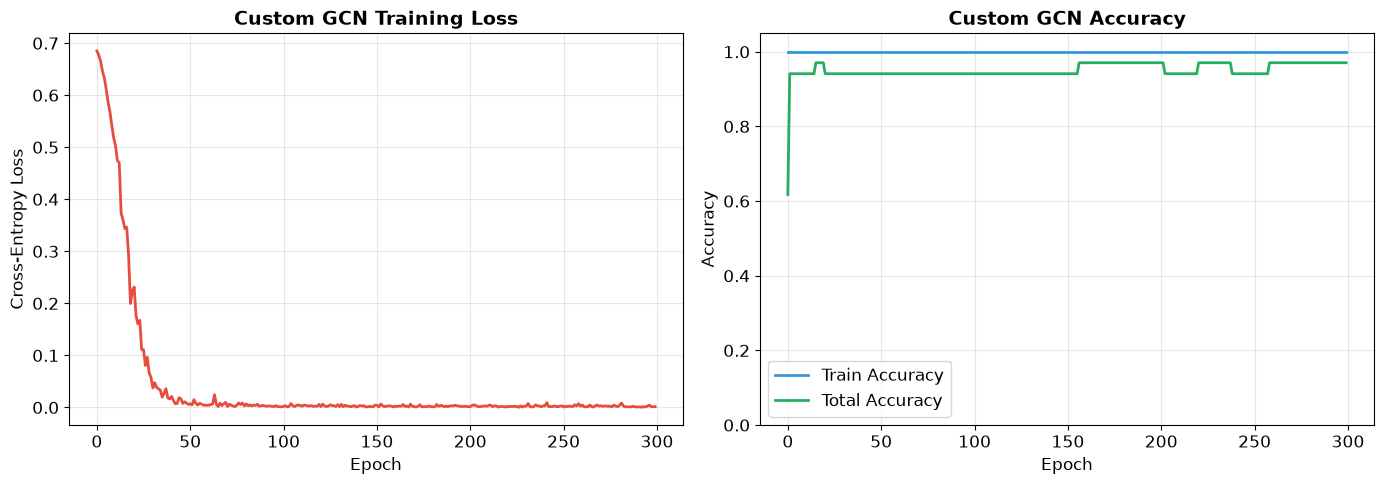

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(custom_losses, color="#E74C3C", linewidth=2)
axes[0].set_title("Custom GCN Training Loss", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].grid(True, alpha=0.3)

axes[1].plot(custom_train_accs, color="#3498DB", linewidth=2, label="Train Accuracy")
axes[1].plot(custom_full_accs, color="#27AE60", linewidth=2, label="Total Accuracy")
axes[1].set_title("Custom GCN Accuracy", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend(fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 1.05])
plt.tight_layout()
plt.show()

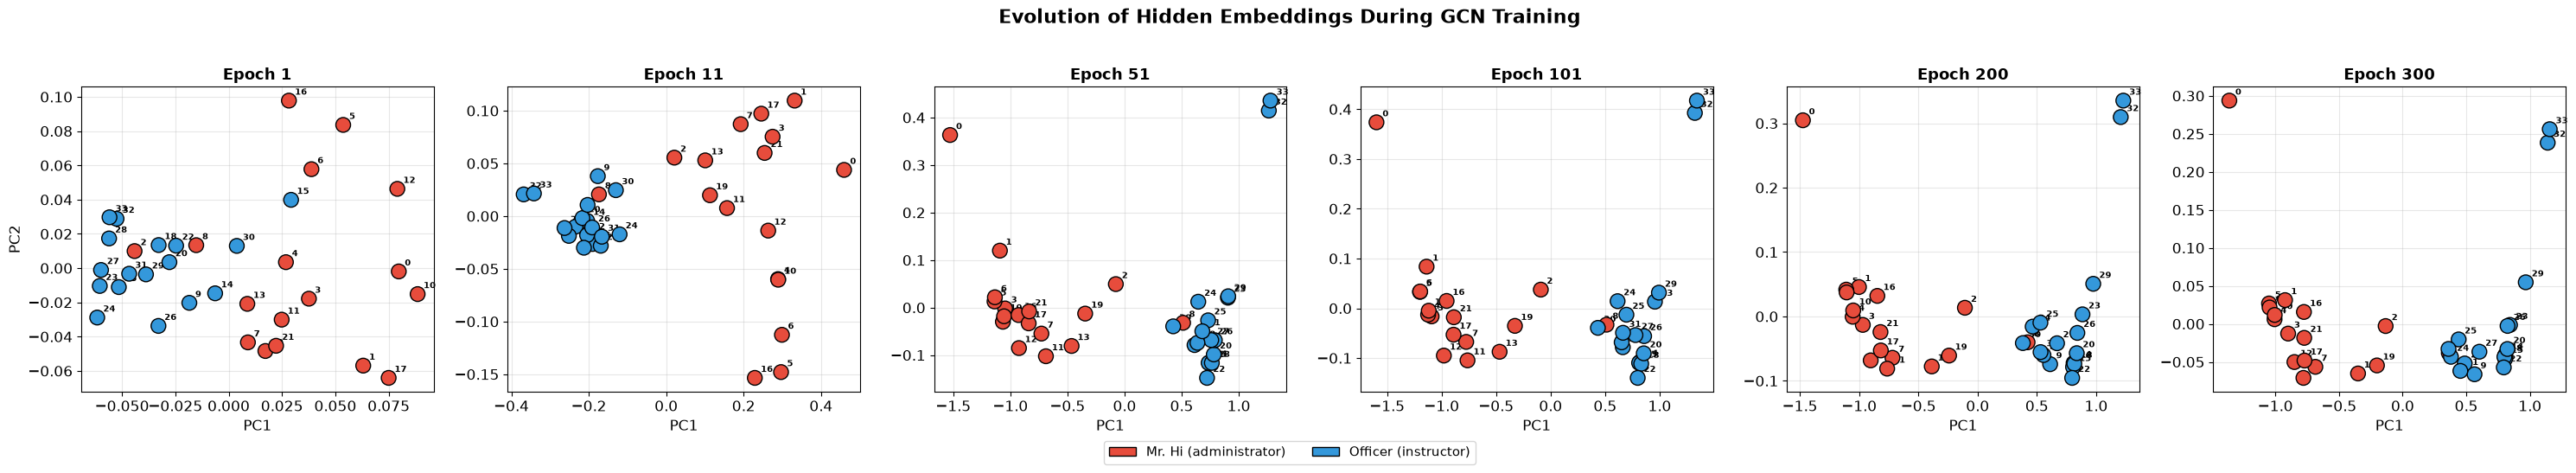

In [31]:
snapshot_epochs = [
    epoch for epoch in sorted(embedding_snapshots.keys()) if epoch <= 299
]
fig, axes = plt.subplots(1, len(snapshot_epochs), figsize=(5 * len(snapshot_epochs), 5))
community_colors = club_color_list(labels)

for idx, epoch in enumerate(snapshot_epochs):
    h = embedding_snapshots[epoch].numpy()
    h_2d = PCA(n_components=2).fit_transform(h)
    axes[idx].scatter(h_2d[:, 0], h_2d[:, 1], c=community_colors, s=150, edgecolors="black", linewidths=1, zorder=5)
    for j in range(num_nodes):
        axes[idx].annotate(str(j), (h_2d[j, 0], h_2d[j, 1]), textcoords="offset points", xytext=(5, 5), fontsize=7, fontweight="bold")
    axes[idx].set_title(f"Epoch {epoch + 1}", fontsize=13, fontweight="bold")
    axes[idx].set_xlabel("PC1")
    axes[idx].set_ylabel("PC2" if idx == 0 else "")
    axes[idx].grid(True, alpha=0.3)

fig.legend(
    handles=[
        mpatches.Patch(facecolor=CLUB_COLORS[i], edgecolor="black", label=CLUB_NAMES[i])
        for i in range(num_classes)
    ],
    loc="lower center",
    ncol=2,
    fontsize=11,
    bbox_to_anchor=(0.5, -0.05),
)
fig.suptitle("Evolution of Hidden Embeddings During GCN Training", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---

# 7. Graph Deep Learning Libraries

## 7.1. Built-in GCNConv vs. custom layer

In [34]:
class PyGGCN(nn.Module):
    '''Same 2-layer architecture, but using PyG GCNConv.'''

    def __init__(self, num_features, num_classes, hidden_dim=16):
        super().__init__()
        self.conv1 = GCNConv(num_features, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, num_classes)
        self.dropout = nn.Dropout(p=0.5)

    def forward(self, x, edge_index, return_hidden=False):
        h = self.conv1(x, edge_index)
        h = F.relu(h)
        h = self.dropout(h)
        logits = self.conv2(h, edge_index)
        if return_hidden:
            return h, logits
        return logits


torch.manual_seed(42)
pyg_model = PyGGCN(data.num_node_features, num_classes)
pyg_losses, pyg_train_accs, pyg_full_accs, _ = train_sparse_model(
    pyg_model, data, name="the PyG GCNConv model"
)

Training the PyG GCNConv model
Epoch  20/300 | Loss: 0.1257 | Train Acc: 1.0000 | Total Acc: 0.9412
Epoch  40/300 | Loss: 0.0116 | Train Acc: 1.0000 | Total Acc: 0.9412
Epoch  60/300 | Loss: 0.0037 | Train Acc: 1.0000 | Total Acc: 0.9412
Epoch  80/300 | Loss: 0.0027 | Train Acc: 1.0000 | Total Acc: 0.9412
Epoch 100/300 | Loss: 0.0011 | Train Acc: 1.0000 | Total Acc: 0.9412
Epoch 120/300 | Loss: 0.0057 | Train Acc: 1.0000 | Total Acc: 0.9412
Epoch 140/300 | Loss: 0.0008 | Train Acc: 1.0000 | Total Acc: 0.9412
Epoch 160/300 | Loss: 0.0007 | Train Acc: 1.0000 | Total Acc: 0.9412
Epoch 180/300 | Loss: 0.0015 | Train Acc: 1.0000 | Total Acc: 0.9706
Epoch 200/300 | Loss: 0.0011 | Train Acc: 1.0000 | Total Acc: 0.9412
Epoch 220/300 | Loss: 0.0005 | Train Acc: 1.0000 | Total Acc: 0.9412
Epoch 240/300 | Loss: 0.0029 | Train Acc: 1.0000 | Total Acc: 0.9412
Epoch 260/300 | Loss: 0.0019 | Train Acc: 1.0000 | Total Acc: 0.9412
Epoch 280/300 | Loss: 0.0014 | Train Acc: 1.0000 | Total Acc: 0.9706
Epo

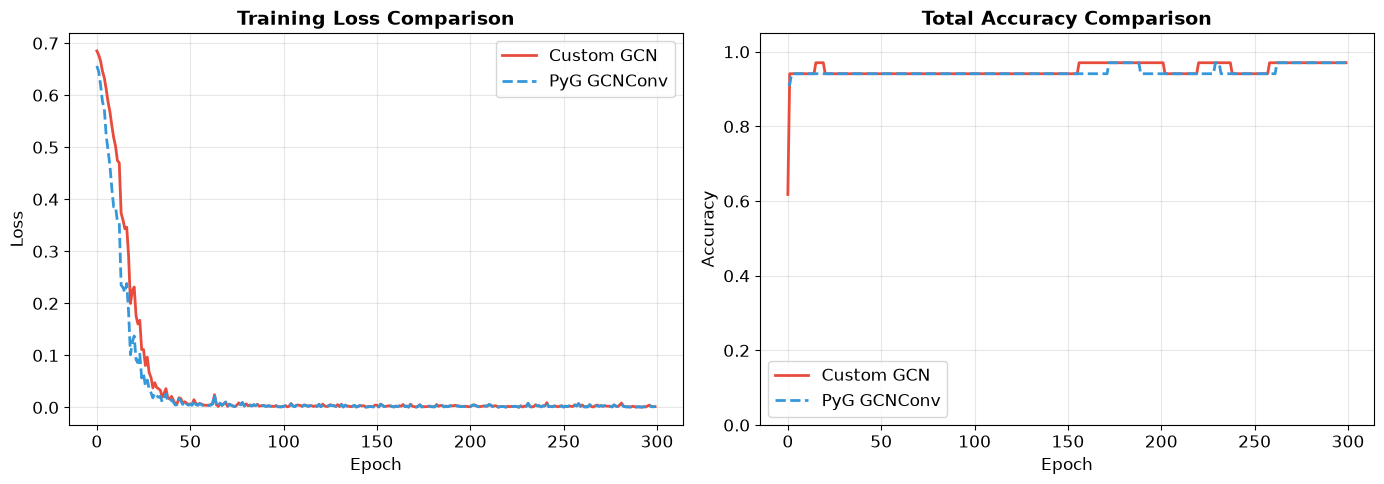

Final total accuracy - Label Propagation: 0.9706
Final total accuracy - Basic mean GNN:    0.9706
Final total accuracy - Scratch GCN:       0.9706
Final total accuracy - Custom GCN:        0.9706
Final total accuracy - PyG GCNConv:       0.9706


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(custom_losses, color="#E74C3C", linewidth=2, label="Custom GCN")
axes[0].plot(pyg_losses, color="#3498DB", linewidth=2, linestyle="--", label="PyG GCNConv")
axes[0].set_title("Training Loss Comparison", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend(fontsize=12)
axes[0].grid(True, alpha=0.3)

axes[1].plot(custom_full_accs, color="#E74C3C", linewidth=2, label="Custom GCN")
axes[1].plot(pyg_full_accs, color="#3498DB", linewidth=2, linestyle="--", label="PyG GCNConv")
axes[1].set_title("Total Accuracy Comparison", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend(fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 1.05])
plt.tight_layout()
plt.show()

print(f"Final total accuracy - Label Propagation: {lp_full_acc:.4f}")
print(f"Final total accuracy - Basic mean GNN:    {basic_full_accs[-1]:.4f}")
print(f"Final total accuracy - Scratch GCN:       {gcn_full_accs[-1]:.4f}")
print(f"Final total accuracy - Custom GCN:        {custom_full_accs[-1]:.4f}")
print(f"Final total accuracy - PyG GCNConv:       {pyg_full_accs[-1]:.4f}")

## 7.2. Predictions on the graph

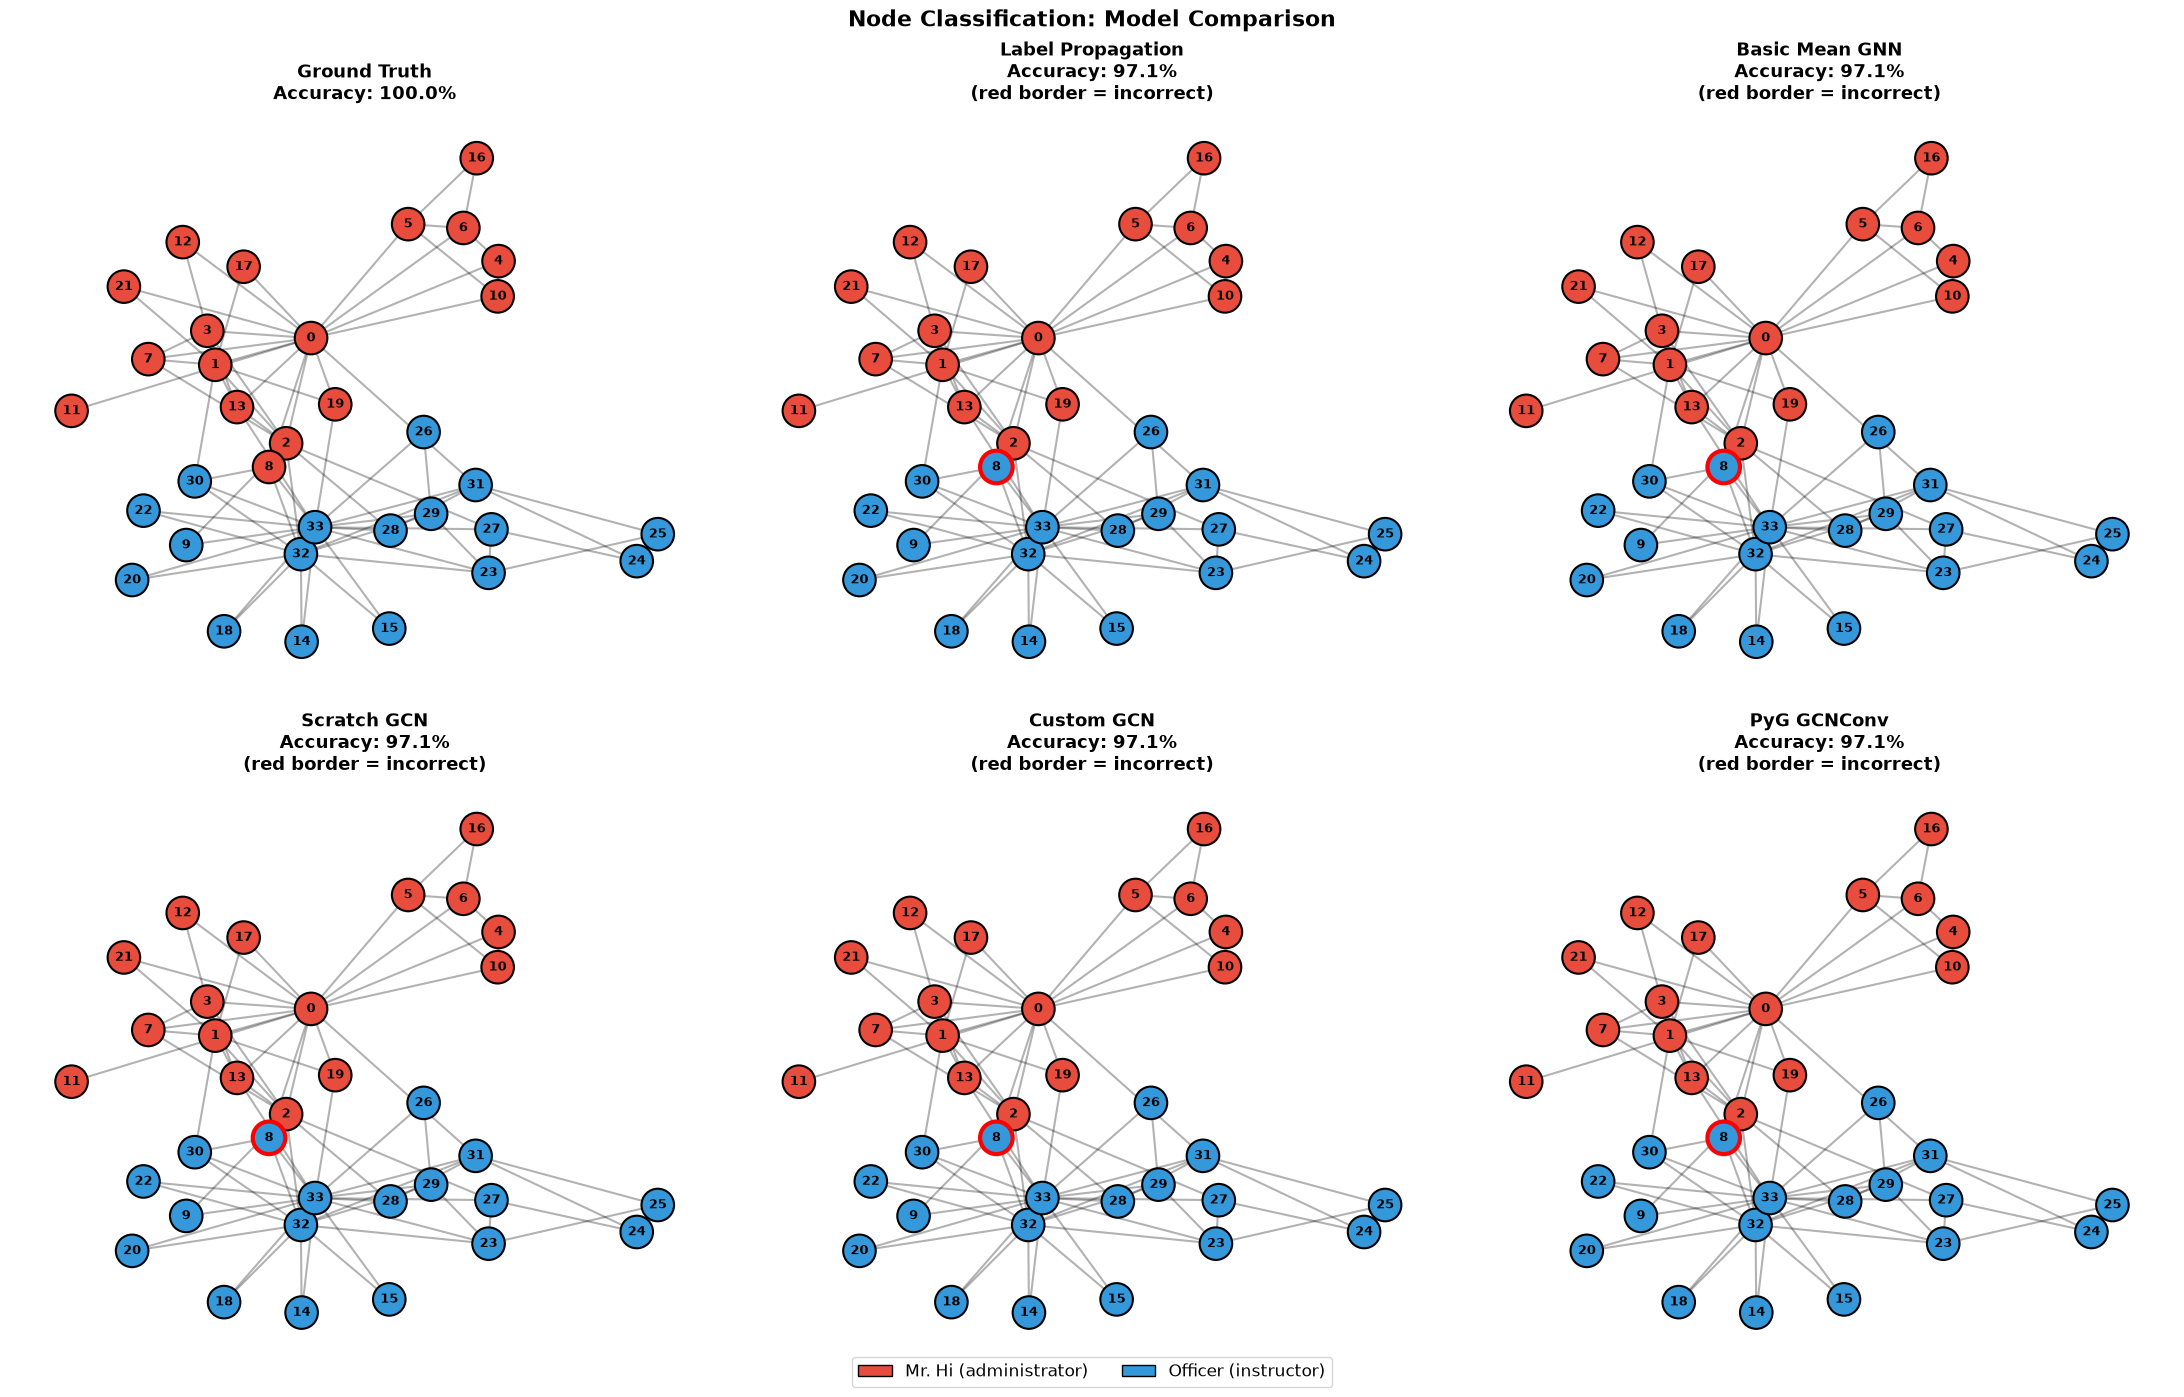

Misclassified nodes
  Label Propagation: [8]
  Basic Mean GNN:    [8]
  Scratch GCN:       [8]
  Custom GCN:        [8]
  PyG GCNConv:       [8]


In [35]:
basic_gnn.eval()
scratch_gcn.eval()
custom_model.eval()
pyg_model.eval()

with torch.no_grad():
    basic_pred = basic_gnn(data.x, adj).argmax(dim=1).cpu().numpy()
    scratch_pred = scratch_gcn(data.x, A_hat).argmax(dim=1).cpu().numpy()
    custom_pred = custom_model(data.x, data.edge_index).argmax(dim=1).cpu().numpy()
    pyg_pred = pyg_model(data.x, data.edge_index).argmax(dim=1).cpu().numpy()

fig, axes = plt.subplots(2, 3, figsize=(22, 14))
axes = axes.flatten()
titles_and_preds = [
    ("Ground Truth", labels, None),
    ("Label Propagation", lp_pred, lp_pred != labels),
    ("Basic Mean GNN", basic_pred, basic_pred != labels),
    ("Scratch GCN", scratch_pred, scratch_pred != labels),
    ("Custom GCN", custom_pred, custom_pred != labels),
    ("PyG GCNConv", pyg_pred, pyg_pred != labels),
]

for ax, (title, y_hat, incorrect) in zip(axes, titles_and_preds):
    borders = ["red" if incorrect is not None and incorrect[i] else "black" for i in range(num_nodes)]
    widths = [3 if incorrect is not None and incorrect[i] else 1.5 for i in range(num_nodes)]
    nx.draw_networkx_edges(G, pos, alpha=0.3, width=1.5, ax=ax)
    nx.draw_networkx_nodes(
        G,
        pos,
        node_color=club_color_list(y_hat),
        node_size=550,
        edgecolors=borders,
        linewidths=widths,
        ax=ax,
    )
    nx.draw_networkx_labels(G, pos, font_size=9, font_weight="bold", ax=ax)
    acc = (np.asarray(y_hat) == labels).mean()
    extra = "\n(red border = incorrect)" if incorrect is not None else ""
    ax.set_title(f"{title}\nAccuracy: {acc:.1%}{extra}", fontsize=13, fontweight="bold")
    ax.axis("off")

fig.legend(
    handles=[
        mpatches.Patch(facecolor=CLUB_COLORS[i], edgecolor="black", label=CLUB_NAMES[i])
        for i in range(num_classes)
    ],
    loc="lower center",
    ncol=2,
    fontsize=12,
    bbox_to_anchor=(0.5, -0.01),
)
fig.suptitle("Node Classification: Model Comparison", fontsize=16, fontweight="bold", y=0.98)
plt.tight_layout()
plt.show()

print("Misclassified nodes")
print(f"  Label Propagation: {np.where(lp_pred != labels)[0].tolist()}")
print(f"  Basic Mean GNN:    {np.where(basic_pred != labels)[0].tolist()}")
print(f"  Scratch GCN:       {np.where(scratch_pred != labels)[0].tolist()}")
print(f"  Custom GCN:        {np.where(custom_pred != labels)[0].tolist()}")
print(f"  PyG GCNConv:       {np.where(pyg_pred != labels)[0].tolist()}")